In [1]:
import glob,os
import numpy as np
import pandas as pd
import matplotlib as mpl
from pathlib import Path
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec



In [2]:
# Models used
dic_sntype = {'50':'Kasen','51':'Bulla'}

# Plotting
dic_band_colors = {
    'LSST-u': '#6A1B9A',   # slightly darker purple, distinct from blue & teal
    'LSST-g': '#3C8DFF',   # light blue (unchanged)
    'LSST-r': '#15284F',   # dark blue/navy (unchanged)
    'LSST-i': '#E69F00',   # orange (unchanged)
    'LSST-z': '#F5622E',   # reddish-orange (unchanged)
    'LSST-Y': '#FFD600'    # golden yellow, cooler than bright yellow, still high contrast
}

dic_KN_models_colors = {
    "Bulla": '#15284F',
    "Kasen": '#f5622e',
}

dic_limiting_mags = {
    'LSST-u': 23.9,
    'LSST-g': 25.0,
    'LSST-r': 24.7,
    'LSST-i': 24.0,
    'LSST-z': 23.3,
    'LSST-Y': 22.1
}


mpl.rcParams["font.size"] = 14            # default text (tick labels, legend, etc.)
mpl.rcParams["axes.titlesize"] = 14       # title font size
mpl.rcParams["axes.labelsize"] = 14       # x and y labels font size
mpl.rcParams["legend.fontsize"] = 12      # legend
mpl.rcParams["xtick.labelsize"] = 12      # x tick labels
mpl.rcParams["ytick.labelsize"] = 12      # y tick labels
mpl.rcParams["legend.fontsize"] = "medium"
mpl.rcParams["figure.titlesize"] = "large"
mpl.rcParams["lines.linewidth"] = 3
mpl.rcParams["patch.linewidth"] = 3 

os.mkdir('paper_plots/obsv43')

In [3]:
# Rubin DDFs
data = {
    'Field': ['ELAISS1', 'XMM_LSS', 'ECDFS', 'COSMOS', 'EDFS_a', 'EDFS_b'],
    'RA': [9.45, 35.57, 52.98, 150.11, 58.9, 63.6],
    'DEC': [-44.02, -4.82, -28.12, 2.23, -49.32, -47.6],
    'Gal l': [311.29, 171.1, 224.07, 236.78, 257.9, 254.48],
    'Gal b': [-72.88, -58.91, -54.6, 42.13, -48.46, -45.77],
    'Eclip l': [346.66, 31.59, 40.81, 151.39, 32, 40.97],
    'Eclip b': [-43.2, -17.92, -45.44, -9.34, -66.61, -66.6]
}

ddf_fields = pd.DataFrame(data)
ddf_fields


,Field,RA,DEC,Gal l,Gal b,Eclip l,Eclip b
0,ELAISS1,9.45,-44.02,311.29,-72.88,346.66,-43.20
1,XMM_LSS,35.57,-4.82,171.10,-58.91,31.59,-17.92
2,ECDFS,52.98,-28.12,224.07,-54.60,40.81,-45.44
3,COSMOS,150.11,2.23,236.78,42.13,151.39,-9.34
4,EDFS_a,58.90,-49.32,257.90,-48.46,32.00,-66.61
5,EDFS_b,63.60,-47.60,254.48,-45.77,40.97,-66.60


In [4]:

def convert_fluxcal_to_mag(df):
    """_summary_

    Args:
        df (_type_): _description_
    """
    # Convert fluxcal to magnitude
    df = df.copy()
    df["magnitude"] = -2.5 * np.log10(df["FLUXCAL"]) + 27.5
    df["magnitude error"] = 2.5 / np.log(10) * df["FLUXCALERR"] / df["FLUXCAL"]
    return df

def read_fits(fname, drop_separators=False):
    """Load SNANA formatted data and cast it to a PANDAS dataframe

    Args:
        fname (str): path + name to PHOT.FITS file
        drop_separators (Boolean): if -777 are to be dropped

    Returns:
        (pandas.DataFrame) dataframe from PHOT.FITS file (with ID)
        (pandas.DataFrame) dataframe from HEAD.FITS file
    """

    # load photometry
    dat = Table.read(fname, format="fits")
    df_phot = dat.to_pandas()
    # failsafe
    if df_phot.MJD.values[-1] == -777.0:
        df_phot = df_phot.drop(df_phot.index[-1])
    if df_phot.MJD.values[0] == -777.0:
        df_phot = df_phot.drop(df_phot.index[0])

    # load header
    header = Table.read(fname.replace("PHOT", "HEAD"), format="fits")
    df_header = header.to_pandas()
    # fix to make SNID unique
    
    # Decode bytes and strip whitespace
    df_header["SNID"] = df_header["SNID"].str.decode("utf-8").str.strip()
    # Map SNTYPE and concatenate
    df_header['model_name'] = df_header["SNTYPE"].astype(str).map(dic_sntype)
    suffix = df_header['model_name'][0]
    # to disentangle the SNIDs from the two models (issue with sim, not unique)
    df_header["SNID"] = df_header["SNID"] + f"_{suffix}"


    # add SNID to phot for skimming
    arr_ID = np.empty(len(df_phot), dtype=object)  # allocate as string
    arr_idx = np.where(df_phot["MJD"].values == -777.0)[0]
    arr_idx = np.hstack((np.array([0]), arr_idx, np.array([len(df_phot)])))
    for counter in range(1, len(arr_idx)):
        start, end = arr_idx[counter - 1], arr_idx[counter]
        snid_str = str(df_header.SNID.iloc[counter - 1])
        arr_ID[start:end] = snid_str
    df_phot["SNID"] = arr_ID

    if drop_separators:
        df_phot = df_phot[df_phot.MJD != -777.000]

    df_phot['SNR'] = np.abs(df_phot['FLUXCAL'] / df_phot['FLUXCALERR'])
    df_phot = convert_fluxcal_to_mag(df_phot)
    df_phot["BAND"] = df_phot["BAND"].str.decode('utf-8').str.strip()

    # Add model name (not optimised)
    df_phot["model_name"] = df_phot["SNID"].str.split("_").str[1]

    # Add DDF
    # Initialize new columns
    df_header["in_ddf_field"] = False
    df_header["ddf_field_name"] = np.nan

    # Convert df_header RA/DEC to SkyCoord
    coords_header = SkyCoord(ra=df_header["RA"].values * u.deg,
                            dec=df_header["DEC"].values * u.deg)
    # Radius of 9.6 deg² -> ~1.75 deg
    radius_deg = np.sqrt(9.6 / np.pi)
    # Loop through DDF fields
    for _, row in ddf_fields.iterrows():
        field = row["Field"]
        ra = row["RA"]
        dec = row["DEC"]
        
        # Convert field center to SkyCoord
        field_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
        
        # Compute angular separation
        separation = coords_header.separation(field_coord)
        
        # Find objects within radius
        within = separation <= radius_deg * u.deg
        
        df_header.loc[within, "in_ddf_field"] = True
        df_header.loc[within, "ddf_field_name"] = field

    return df_header, df_phot


In [5]:

df_header_list=[]
df_phot_list=[]
list_to_read = glob.glob("./data/obsv43/*/*PHOT.FITS.gz")
print(f"Found {len(list_to_read)} PHOT.FITS.gz files to read.")
for fphot in list_to_read:
    df_header_tmp, df_phot_tmp = read_fits(fphot, drop_separators=True)
    print(f"Reading {fphot} with length {len(df_phot_tmp)}")
    df_header_list.append(df_header_tmp)
    df_phot_list.append(df_phot_tmp)
df_header = pd.concat(df_header_list, ignore_index=True)
# Read all PHOT.FITS.gz files and concatenate them    
df_phot = pd.concat(df_phot_list, ignore_index=True)
print(f"Number of light curves: {len(df_header)}")
print(f"Number of photometric points: {df_phot.groupby('SNID').count()['MJD'].median()} +- {df_phot.groupby('SNID').count()['MJD'].std()}")

Found 2 PHOT.FITS.gz files to read.


/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/920436591.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ELAISS1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_header.loc[within, "ddf_field_name"] = field


Reading ./data/obsv43/PIP_AMR_KN_LSST_KN_BULLA_NOHOST/PIP_AMR_KN_LSST_KN_BULLA_ab08d_NONIaMODEL00-0001_PHOT.FITS.gz with length 131504


/Users/amoller/Science/KN_OzGrav/KNcand_LVK/Rubin_KNe_with_Fink_LVK/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/920436591.py:94: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'ELAISS1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_header.loc[within, "ddf_field_name"] = field


Reading ./data/obsv43/PIP_AMR_KN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_LSST_KN_KASEN_81c4b_NONIaMODEL00-0001_PHOT.FITS.gz with length 131504
Number of light curves: 11528
Number of photometric points: 18.0 +- 48.283732624944086


In [6]:
df_header.groupby('model_name').count()['SNID']

model_name
Bulla    5764
Kasen    5764
Name: SNID, dtype: int64

In [7]:
dic_gt5 = {}
for typ in df_header.SIM_GENTYPE.unique():
    
    # Select matching SNIDs from df_phot
    sel_snids = df_header[df_header.SIM_GENTYPE == typ].SNID
    print(f"\nNumber of light curves with SIM_GENTYPE = {typ} | {dic_sntype[str(typ)]}: {len(sel_snids)}")

    # Total SNIDs for this SIM_GENTYPE
    total_typ_snids = len(sel_snids)

    # Photometry
    sel = df_phot[df_phot.SNID.isin(sel_snids)]
    print(f"Number of photometric points for this type: {len(sel)}")

    # Compute SNR thresholds
    typ_str = dic_sntype[f"{typ}"]
    dic_gt5[typ_str] = sel[sel['SNR'] > 5]
    snr_gt_5 = dic_gt5[typ_str]['SNID'].nunique()
    snr_gt_3 = sel[sel['SNR'] > 3]['SNID'].nunique()

    # Group by SNID, count how many SNR > 5 measurements each has
    snr_gt5_counts = dic_gt5[typ_str].groupby('SNID').size()

    # Count how many SNIDs have at least two such measurements
    snr_gt5_atleast2 = (snr_gt5_counts >= 2).sum()

    # Group by SNID and check MJD separation
    def has_two_sep_days(group):
        mjds = group['MJD'].sort_values().values
        for i in range(len(mjds)):
            for j in range(i+1, len(mjds)):
                if abs(mjds[j] - mjds[i]) > 1:
                    return True
        return False

    # Apply the function to each group
    snids_with_two_sep_days = dic_gt5[typ_str].groupby('SNID').filter(has_two_sep_days)['SNID'].nunique()
    

    print(f"{snr_gt_5} light curves have 1 detection with SNR > 5 = {snr_gt_5 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snr_gt5_atleast2} light curves have 2 detections with SNR > 5 = {snr_gt5_atleast2 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snids_with_two_sep_days} light curves have 2 detections with SNR > 5 in >1 day = {snids_with_two_sep_days / total_typ_snids * 100:.2f}% of this type")

    print("")
    print(f"{snr_gt_3} light curves have 1 detection with SNR > 3 = {snr_gt_3 / total_typ_snids * 100:.2f}% of this type")



Number of light curves with SIM_GENTYPE = 51 | Bulla: 5764
Number of photometric points for this type: 131504
623 light curves have 1 detection with SNR > 5 = 10.81% of this type
365 light curves have 2 detections with SNR > 5 = 6.33% of this type
84 light curves have 2 detections with SNR > 5 in >1 day = 1.46% of this type

1167 light curves have 1 detection with SNR > 3 = 20.25% of this type

Number of light curves with SIM_GENTYPE = 50 | Kasen: 5764
Number of photometric points for this type: 131504
404 light curves have 1 detection with SNR > 5 = 7.01% of this type
236 light curves have 2 detections with SNR > 5 = 4.09% of this type
91 light curves have 2 detections with SNR > 5 in >1 day = 1.58% of this type

937 light curves have 1 detection with SNR > 3 = 16.26% of this type


In [8]:
for typ in dic_gt5.keys():
    # Count number of rows with SNR > 5 per BAND
    snr_gt5_by_band = dic_gt5[typ_str].groupby('BAND').size()

    # Find the BAND with the most such entries
    most_common_band = snr_gt5_by_band.idxmax()
    count_most_common_band = snr_gt5_by_band.max()
    print(f"{typ}: The most common BAND with SNR > 5 is {most_common_band} with {count_most_common_band} entries.")
    print(snr_gt5_by_band)
# Combine SNIDs from both models
snids_all_snr_gt5 = np.concatenate([
    dic_gt5['Bulla'].SNID.values, 
    dic_gt5['Kasen'].SNID.values
])

Bulla: The most common BAND with SNR > 5 is LSST-i with 315 entries.
BAND
LSST-Y     48
LSST-g     65
LSST-i    315
LSST-r    312
LSST-u      4
LSST-z    156
dtype: int64
Kasen: The most common BAND with SNR > 5 is LSST-i with 315 entries.
BAND
LSST-Y     48
LSST-g     65
LSST-i    315
LSST-r    312
LSST-u      4
LSST-z    156
dtype: int64


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/2900313165.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/2900313165.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x)

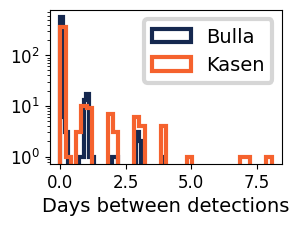

In [9]:
def delta_days(group):
    mjds = group['MJD'].sort_values().values
    for i in range(len(mjds)):
        for j in range(i+1, len(mjds)):
            return mjds[j] - mjds[i]
    return 0
fig = plt.figure(figsize=(3, 2))
for typ in dic_gt5.keys():
    snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
    plt.hist(snids_count_sep_days, bins=40, histtype='step',label=typ,color=dic_KN_models_colors[typ])
plt.yscale('log')
plt.xlabel('Days between detections')
plt.legend()

Text(0.5, 0, 'Simulated redshift')

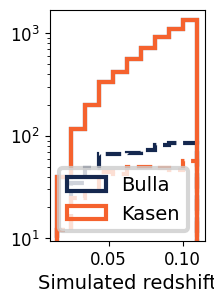

In [10]:
fig = plt.figure(figsize=(2,3))
color_list = ['blue','orange']
for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    plt.hist(sel['SIM_REDSHIFT_CMB'], label=model, histtype='step', color= dic_KN_models_colors[model])
    # SNR>5
    sel = sel[sel.SNID.isin(snids_all_snr_gt5)]
    plt.hist(sel['SIM_REDSHIFT_CMB'], histtype='step', color= dic_KN_models_colors[model], linestyle='dashed')
plt.legend()
plt.yscale('log')
plt.xlabel('Simulated redshift')

/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/769157129.py:24: RuntimeWarning: invalid value encountered in divide
  efficiency = counts_snr / counts_sim
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/769157129.py:26: RuntimeWarning: invalid value encountered in divide
  err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/769157129.py:27: RuntimeWarning: invalid value encountered in divide
  (err_sim / counts_sim) ** 2) * efficiency


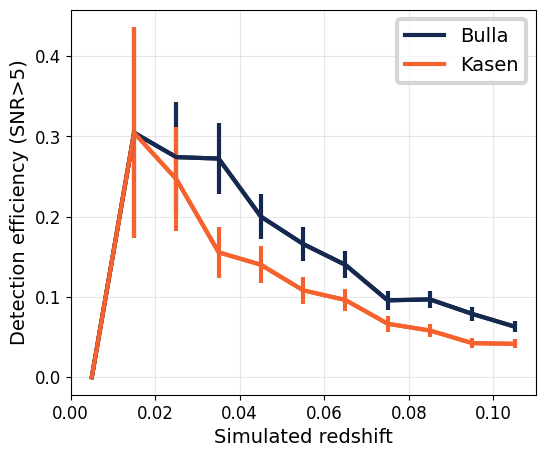

In [11]:
fig = plt.figure(figsize=(6,5))
ax = plt.gca()
color_list = ['blue', 'orange']

# Define redshift bins
bins = np.linspace(0, max(df_header['SIM_REDSHIFT_CMB']), 12)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    
    # All events
    counts_sim, _ = np.histogram(sel['SIM_REDSHIFT_CMB'], bins=bins)
    
    # Events with SNR > 5
    sel_snr = sel[sel.SNID.isin(snids_all_snr_gt5)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)

    # add errors
    err_data = np.sqrt(counts_snr)
    err_sim = np.sqrt(counts_sim)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_sim
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
                        (err_sim / counts_sim) ** 2) * efficiency
    err_efficiency = np.nan_to_num(err_efficiency)
    
    ax.plot(bin_centers, efficiency,  color=dic_KN_models_colors[model], label=model)
    ax.errorbar(bin_centers, efficiency, yerr=err_efficiency, color=dic_KN_models_colors[model])

ax.set_xlabel('Simulated redshift')
ax.set_ylabel('Detection efficiency (SNR>5)')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig('paper_plots/obsv43/efficiency_alert_vs_redshift.png')



/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/4210500681.py:28: RuntimeWarning: invalid value encountered in divide
  efficiency = counts_snr / counts_sim
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/4210500681.py:30: RuntimeWarning: invalid value encountered in divide
  err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/4210500681.py:31: RuntimeWarning: invalid value encountered in divide
  (err_sim / counts_sim) ** 2) * efficiency


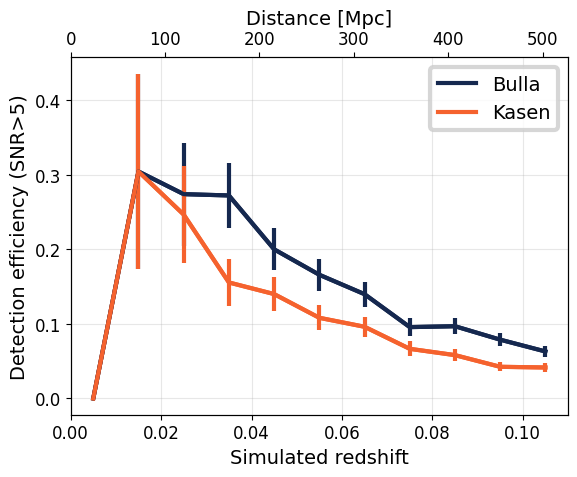

In [12]:
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
import numpy as np

fig = plt.figure(figsize=(6,5))
ax = plt.gca()
color_list = ['blue', 'orange']

# Define redshift bins
bins = np.linspace(0, max(df_header['SIM_REDSHIFT_CMB']), 12)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    
    # All events
    counts_sim, _ = np.histogram(sel['SIM_REDSHIFT_CMB'], bins=bins)
    
    # Events with SNR > 5
    sel_snr = sel[sel.SNID.isin(snids_all_snr_gt5)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)

    # add errors
    err_data = np.sqrt(counts_snr)
    err_sim = np.sqrt(counts_sim)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_sim
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    err_efficiency = np.sqrt((err_data / counts_snr) ** 2 +
                             (err_sim / counts_sim) ** 2) * efficiency
    err_efficiency = np.nan_to_num(err_efficiency)
    
    ax.plot(bin_centers, efficiency, color=dic_KN_models_colors[model], label=model)
    ax.errorbar(bin_centers, efficiency, yerr=err_efficiency, color=dic_KN_models_colors[model])

ax.set_xlabel('Simulated redshift')
ax.set_ylabel('Detection efficiency (SNR>5)')
ax.legend()
ax.grid(alpha=0.3)

# --- Add secondary x-axis for distance ---
def z_to_mpc(z):
    return cosmo.luminosity_distance(z).value  # in Mpc

ax2 = ax.twiny()
ax2.set_xlim(z_to_mpc(ax.get_xlim()[0]), z_to_mpc(ax.get_xlim()[1]))
ax2.set_xlabel('Distance [Mpc]')

plt.tight_layout()
# plt.savefig('paper_plots/obsv43/efficiency_alert_vs_redshift.png')


### Rubin Deep Drilling Fields

In [13]:
# Calculate counts
count_ddf = df_header['in_ddf_field'].sum()
total_count = len(df_header)
total_selected = len(df_header[df_header.SNID.isin(snids_all_snr_gt5)])

print(
    f"# Lcs in DDF fields: {count_ddf} = "
    f"{np.round(count_ddf * 100 / total_count, 2)}% of all lcs = "
    f"{np.round(count_ddf * 100 / total_selected, 2)}% of all lcs SNR>5"
)
print("DDF fields with light curves:")
for field in ddf_fields['Field']:
    count = df_header[df_header['ddf_field_name'] == field].shape[0]
    print(f"{field}: {count} light curves")
# Save the header and photometry dataframes to CSV files

# Lcs in DDF fields: 50 = 0.43% of all lcs = 4.87% of all lcs SNR>5
DDF fields with light curves:
ELAISS1: 6 light curves
XMM_LSS: 14 light curves
ECDFS: 10 light curves
COSMOS: 6 light curves
EDFS_a: 10 light curves
EDFS_b: 4 light curves


/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/3532982510.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


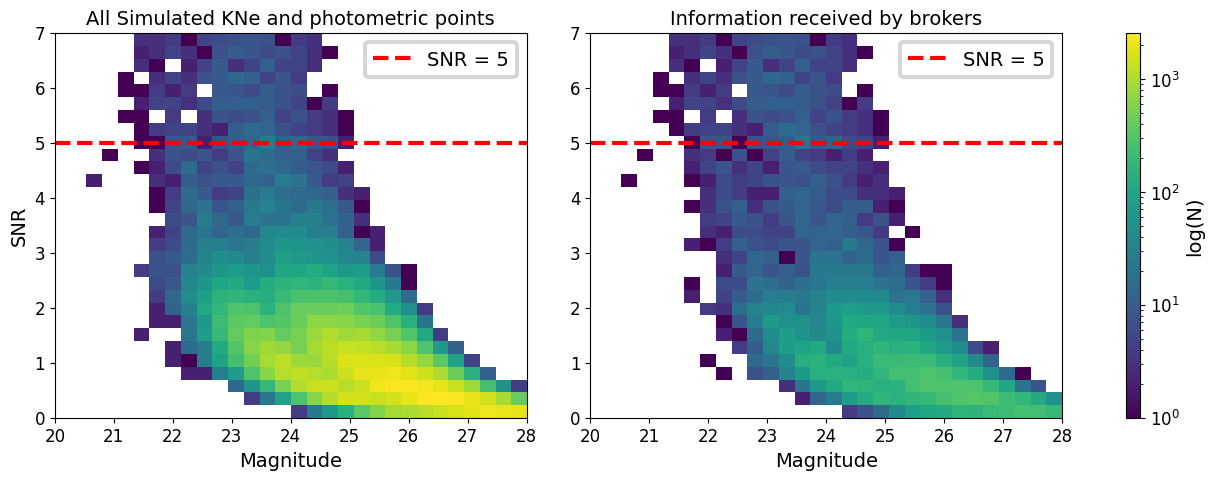

In [14]:
# SNR vs magnitude

# Define bins and ranges
x_bins = 30
y_bins = 30
x_range = [20, 28]
y_range = [0, 7]
bins = [x_bins, y_bins]
range_ = [x_range, y_range]

# Compute 2D histograms manually
H1, _, _ = np.histogram2d(df_phot['magnitude'], df_phot['SNR'],
                          bins=bins, range=range_)
H2, _, _ = np.histogram2d(df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['magnitude'], df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['SNR'],
                          bins=bins, range=range_)

# Determine global vmin and vmax for LogNorm (exclude zeros)
nonzero_counts = np.concatenate([H1.ravel(), H2.ravel()])
nonzero_counts = nonzero_counts[nonzero_counts > 0]
vmin = nonzero_counts.min()
vmax = nonzero_counts.max()

# Create figure with 3 subplots: 2 main plots + 1 thin colorbar subplot
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.03], wspace=0.2)

# First heatmap (left)
ax1 = fig.add_subplot(gs[0])
im1 = ax1.imshow(H1.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax1.set_title('All Simulated KNe and photometric points')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('SNR')
ax1.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax1.legend()

# Second heatmap (middle)
ax2 = fig.add_subplot(gs[1], sharey=ax1)
im2 = ax2.imshow(H2.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax2.set_title('Information received by brokers')
ax2.set_xlabel('Magnitude')
ax2.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax2.legend()

# Colorbar subplot (right, very thin)
cax = fig.add_subplot(gs[2])
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label('log(N)')

plt.tight_layout()
plt.show()


In [15]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def plot_lc_subplots(df_phot, df_header, idx, inmag=False, convert_date=False):
    """Plot multi-panel light curve evolution for a given SNID."""
    
    # --- Select data ---
    sel_phot = df_phot[df_phot.SNID == idx].copy()
    sel_header = df_header[df_header.SNID == idx]

    # Remove bogus mags if plotting in mag space
    if inmag:
        sel_phot = sel_phot[sel_phot["magnitude"] > 0]

    # Init
    bands = sel_phot["BAND"].unique()
    x_col = "TIME" if convert_date else "MJD"
    if convert_date:
        sel_phot["TIME"] = pd.to_datetime(sel_phot["MJD"], unit='D', origin='1858-11-17')

    # Peak time for vertical line
    peakmjd = float(sel_header.PEAKMJD.values[0])
    peak_x = pd.to_datetime(peakmjd, unit='D', origin='1858-11-17') if convert_date else peakmjd

    # Select SNR>5 detections sorted by time
    snr5_df = sel_phot[sel_phot['SNR'] > 5].sort_values('MJD')

    # No alerts
    if len(snr5_df)<1:
        print(f"No alert for {idx}")
        return None
    

    # --- Build datasets to plot
    # First alert
    first_alert = snr5_df.head(1)
    # Second alert
    # with history if Delta time> 1 day (0.6 for a night)
    second_alert = pd.DataFrame()
    if len(snr5_df) >= 2:
        if snr5_df['MJD'].iloc[1] - snr5_df['MJD'].iloc[0] > 0.6:
            second_mjd = snr5_df.iloc[1]['MJD']
            snr_lt5_before_second = sel_phot[(sel_phot['SNR'] < 5) & (sel_phot['MJD'] < second_mjd)]
            second_alert = pd.concat([snr5_df.head(2), snr_lt5_before_second])
        else:
            second_alert = snr5_df.head(2)
    # All the photometry received by the broker
    all_alerts = snr5_df
    last_alert_mjd = snr5_df['MJD'].max()
    if snr5_df['MJD'].max() - snr5_df['MJD'].min()>0.6:
        all_alerts = sel_phot[sel_phot['MJD'] < last_alert_mjd]
        
    full_Rubin_lc = sel_phot.copy()

    datasets = [first_alert, second_alert, all_alerts, full_Rubin_lc]

    # --- Global y-range ---
    if inmag:
        all_y = sel_phot["magnitude"]
        ymin, ymax = all_y.max() + 1, all_y.min() - 1  # reversed for mags
    else:
        all_y = sel_phot["FLUXCAL"]
        ymin, ymax = all_y.min() - 1, all_y.max() + 1

    # --- Subplot titles ---
    base_titles = [
        "1. First alert",
        "2. Second alert",
        "3. All broker data",
        "4. Full Rubin data"
    ]
    subplot_titles = []
    for base, df in zip(base_titles, datasets):
        if df.empty:
            latest = "No data"
        else:
            latest_mjd = df['MJD'].max()
            latest = pd.to_datetime(latest_mjd, unit='D', origin='1858-11-17').strftime('%Y-%m-%d') if convert_date else f"MJD {latest_mjd:.1f}"
        subplot_titles.append(f"{base}<br>{latest}")

    # --- Create figure ---
    fig = make_subplots(
        rows=1, cols=4,
        subplot_titles=subplot_titles,
        shared_yaxes=True
    )

    plotted_labels = set()

    # --- Plot each dataset ---
    for i, dataset in enumerate(datasets):
        if dataset.empty:
            continue
        for flt in bands:
            sel_flt = dataset[dataset["BAND"] == flt]
            yvar, yerr = ("magnitude", "magnitude error") if inmag else ("FLUXCAL", "FLUXCALERR")

            # Plot SNR bins
            for snr_min, snr_max, symbol, opacity, suffix in [
                (5, np.inf, 'circle', 1, "SNR > 5"),
                (1, 5, 'circle', 0.3, "1 < SNR < 5")
            ]:
                mask = (sel_flt['SNR'] > snr_min) & (sel_flt['SNR'] < snr_max)
                label = f"{flt} ({suffix})"
                fig.add_trace(go.Scatter(
                    x=sel_flt.loc[mask, x_col],
                    y=sel_flt.loc[mask, yvar],
                    error_y=dict(
                        type='data',
                        array=sel_flt.loc[mask, yerr],
                        visible=True
                    ),
                    mode='markers',
                    name=label,
                    marker=dict(opacity=opacity, symbol=symbol, size=8, color=dic_band_colors[flt]),
                    showlegend=False, #(label not in plotted_labels)
                ), row=1, col=i+1)
                plotted_labels.add(label)

            # SNR < 1
            mask = sel_flt['SNR'] < 1
            fig.add_trace(go.Scatter(
                x=sel_flt.loc[mask, x_col],
                y=sel_flt.loc[mask, yvar],
                mode='markers',
                marker=dict(opacity=0.2, symbol='triangle-down', size=8, color=dic_band_colors[flt]),
                showlegend=False
            ), row=1, col=i+1)

        # Peak & first detection lines
        fig.add_vline(x=peak_x, line=dict(color="black", width=1, dash="dash"), row=1, col=i+1,layer="below")
        if not dataset[dataset['SNR'] > 5].empty:
            first_snr5_mjd = dataset.loc[dataset['SNR'] > 5, 'MJD'].min()
            first_snr5_x = pd.to_datetime(first_snr5_mjd, unit='D', origin='1858-11-17') if convert_date else first_snr5_mjd
            fig.add_vline(x=first_snr5_x, line=dict(color="blue", width=1.5, dash="dot"), row=1, col=i+1,layer="below")
            last_snr5_mjd = dataset.loc[dataset['SNR'] > 5, 'MJD'].max()
            last_snr5_x = pd.to_datetime(last_snr5_mjd, unit='D', origin='1858-11-17') if convert_date else last_snr5_mjd
            fig.add_vline(x=last_snr5_x, line=dict(color="blue", width=1.5, dash="dot"), row=1, col=i+1,layer="below")

    # Legend-only dummy traces
    for band, color in band_colors.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(color=color, size=30),
            name=band  # appears in legend
        ))

    # --- Layout ---
    z = np.round(float(sel_header.REDSHIFT_FINAL.values[0]), 2)
    sim_type = sel_header.SIM_TYPE_NAME.values[0]
    if isinstance(sim_type, bytes):
        sim_type = sim_type.decode("utf-8")
    ddf_name = sel_header.ddf_field_name.values[0] if sel_header.in_ddf_field.values[0] else "WFD"

    for annotation in fig['layout']['annotations']:
        annotation['font'] = dict(size=30)
                              
    print(f"SNID: {idx} z: {z} {ddf_name}")
    fig.update_layout(
        # title_text=f"SNID: {idx} z: {z} {ddf_name}",
        height=500, width=1500,
        legend=dict(font=dict(size=16)),
        legend_title="Filter",
    )
    fig.update_xaxes(tickangle=30)
    fig.update_yaxes(title_text=("magnitude" if inmag else "FLUXCAL"), range=[ymin, ymax],showgrid=False,title_font=dict(size=30),tickfont=dict(size=16))
    fig.update_xaxes(title_text=("Date" if convert_date else "MJD"),showgrid=False, title_font=dict(size=30),tickfont=dict(size=16))
    fig.show()

def plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=False, convert_date=False, savefig=False):
    """Matplotlib version of plot_lc_subplots"""

    sel_phot = df_phot[df_phot.SNID == idx].copy()
    sel_header = df_header[df_header.SNID == idx]

    if inmag:
        sel_phot = sel_phot[sel_phot["magnitude"] > 0]

    bands = sel_phot["BAND"].unique()
    x_col = "TIME" if convert_date else "MJD"
    if convert_date:
        sel_phot["TIME"] = pd.to_datetime(sel_phot["MJD"], unit="D", origin="1858-11-17")

    peakmjd = float(sel_header.PEAKMJD.values[0])
    peak_x = pd.to_datetime(peakmjd, unit="D", origin="1858-11-17") if convert_date else peakmjd

    snr5_df = sel_phot[sel_phot['SNR'] > 5].sort_values('MJD')
    if len(snr5_df) < 1:
        print(f"No alert for {idx}")
        return None

    # First alert
    first_alert = snr5_df.head(1)

    # Second alert
    second_alert = pd.DataFrame()
    if len(snr5_df) >= 2:
        if snr5_df['MJD'].iloc[1] - snr5_df['MJD'].iloc[0] > 0.6:
            second_mjd = snr5_df.iloc[1]['MJD']
            snr_lt5_before_second = sel_phot[(sel_phot['SNR'] < 5) & (sel_phot['MJD'] < second_mjd)]
            second_alert = pd.concat([snr5_df.head(2), snr_lt5_before_second])
        else:
            second_alert = snr5_df.head(2)

    # Data range second alert
    if not second_alert.empty:
        delta = second_alert[x_col].max() - second_alert[x_col].min()
        second_alert_range = (second_alert[x_col].min()-delta, second_alert[x_col].max()+delta)
    else:
        delta = first_alert[x_col].max() - first_alert[x_col].min()
        second_alert_range = (first_alert[x_col].min()-delta, first_alert[x_col].max()+delta)

    # All broker alerts
    all_alerts = snr5_df
    last_alert_mjd = snr5_df['MJD'].max()
    if snr5_df['MJD'].max() - snr5_df['MJD'].min() > 0.6:
        all_alerts = sel_phot[sel_phot['MJD'] < last_alert_mjd]

    full_Rubin_lc = sel_phot.copy()
    datasets = [first_alert, second_alert, all_alerts, full_Rubin_lc]

    # Global y-range
    if inmag:
        all_y = sel_phot["magnitude"]
        ymin, ymax = all_y.max() + 1, all_y.min() - 1
    else:
        all_y = sel_phot["FLUXCAL"]
        ymin, ymax = all_y.min() - 1, all_y.max() + 1

    # Subplot titles
    base_titles = [
        "1. First alert",
        "2. Second alert",
        "3. All broker data",
        "4. Full Rubin data"
    ]
    subplot_titles = []
    for base, df in zip(base_titles, datasets):
        if df.empty:
            latest = "No data"
        else:
            latest_mjd = df['MJD'].max()
            latest = pd.to_datetime(latest_mjd, unit='D', origin='1858-11-17').strftime('%Y-%m-%d') if convert_date else f"MJD {latest_mjd:.1f}"
        subplot_titles.append(f"{base}\n{latest}")

    # --- Matplotlib figure ---
    fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

    for i, (ax, dataset, title) in enumerate(zip(axes, datasets, subplot_titles)):
        if dataset.empty:
            ax.set_title(title, fontsize=12)
            continue

        for flt in bands:
            sel_flt = dataset[dataset["BAND"] == flt]
            yvar, yerr = ("magnitude", "magnitude error") if inmag else ("FLUXCAL", "FLUXCALERR")

            # SNR bins
            for snr_min, snr_max, marker, alpha, suffix in [
                (5, np.inf, "o", 1, "SNR > 5"),
                (1, 5, "o", 0.3, "1 < SNR < 5")
            ]:
                mask = (sel_flt['SNR'] > snr_min) & (sel_flt['SNR'] < snr_max)
                if len(sel_flt[mask]) > 0:
                    ax.errorbar(
                        sel_flt.loc[mask, x_col],
                        sel_flt.loc[mask, yvar],
                        yerr=sel_flt.loc[mask, yerr],
                        fmt=marker,
                        ms=6,
                        alpha=alpha,
                        color=dic_band_colors[flt],
                        label=f"{flt}" if i == 0 or i==3 else None
                    )

            # SNR < 1
            mask = sel_flt['SNR'] < 1
            if len(sel_flt[mask]) > 0:
                ax.scatter(
                    sel_flt.loc[mask, x_col],
                    sel_flt.loc[mask, yvar],
                    marker="v",
                    alpha=0.2,
                    color=dic_band_colors[flt],
                    label=f"{flt} (SNR < 1)" if i == 0 else None
                )

        # Vertical lines: peak + first/last SNR>5
        ax.axvline(peak_x, color="black", lw=1.5, ls="--", zorder=0)
        if not dataset[dataset['SNR'] > 5].empty and i>0:
            first_snr5 = dataset.loc[dataset['SNR'] > 5, x_col].min()
            last_snr5 = dataset.loc[dataset['SNR'] > 5, x_col].max()
            # ax.axvline(first_snr5, color="blue", lw=1.5, ls=":", zorder=0)
            # ax.axvline(last_snr5, color="blue", lw=1.5, ls=":", zorder=0)
            ax.axvspan(first_snr5, last_snr5, color="#D5D5D3", alpha=0.8, zorder=-1)

        ax.set_title(title, fontsize=12)
        ax.tick_params(axis="x", rotation=30)

    # Y-axis & labels
    axes[0].set_ylabel("magnitude" if inmag else "FLUXCAL")
    for i, ax in enumerate(axes):
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel("Date" if convert_date else "MJD",fontdict={'fontsize': 14})
        if i<2:
            ax.set_xlim(second_alert_range)

    import matplotlib.patches as mpatches

    # Create one legend entry per band
    handles = []
    labels = []
    for band, color in dic_band_colors.items():
        patch = mpatches.Patch(color=color, label=band)  # patch works, but for circle marker we can use Line2D
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8))
        labels.append(band)

    # Place the legend outside, centered vertically
    fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(0.9, 0.5),
        fontsize=10,
        title="Filter"
    )

    # fig.suptitle(f"SNID {idx} z={sel_header.REDSHIFT_FINAL.values[0]:.2f}", fontsize=14)
    print(f"SNID {idx} z={sel_header.REDSHIFT_FINAL.values[0]:.2f}")
    

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05) 

    if savefig:
        plt.savefig(f"paper_plots/obsv43/lc_subplot_{idx}_z_{sel_header.REDSHIFT_FINAL.values[0]:.2f}_{sel_header.in_ddf_field.values[0]}.png")

    
    # plt.show()


# With Alert in broker

/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/212791536.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)
/var/folders/k7/lh2yb1wj70qfbn284kn467680000gp/T/ipykernel_21252/212791536.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(second_alert_range)


SNID 11068_Bulla z=0.10
SNID 2379_Kasen z=0.07
SNID 3667_Kasen z=0.10
SNID 5497_Bulla z=0.10
SNID 5185_Bulla z=0.08


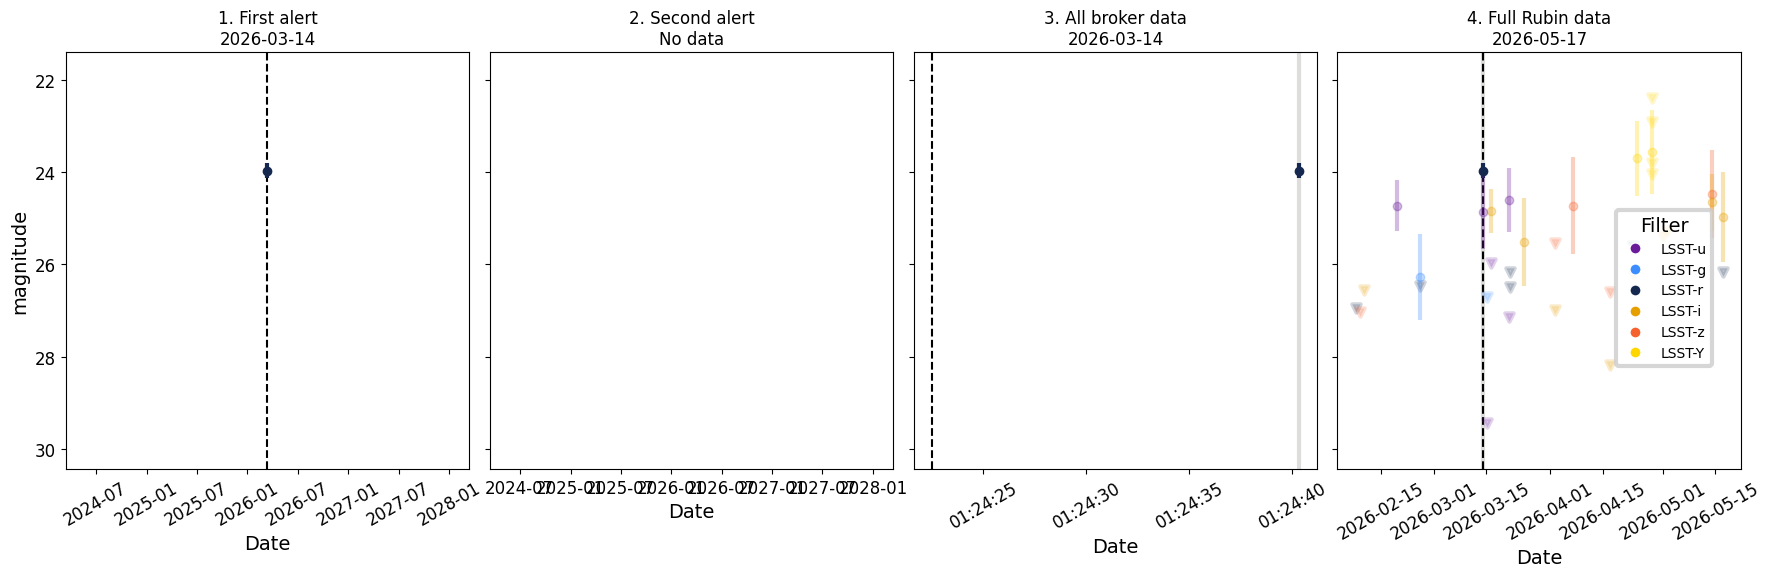

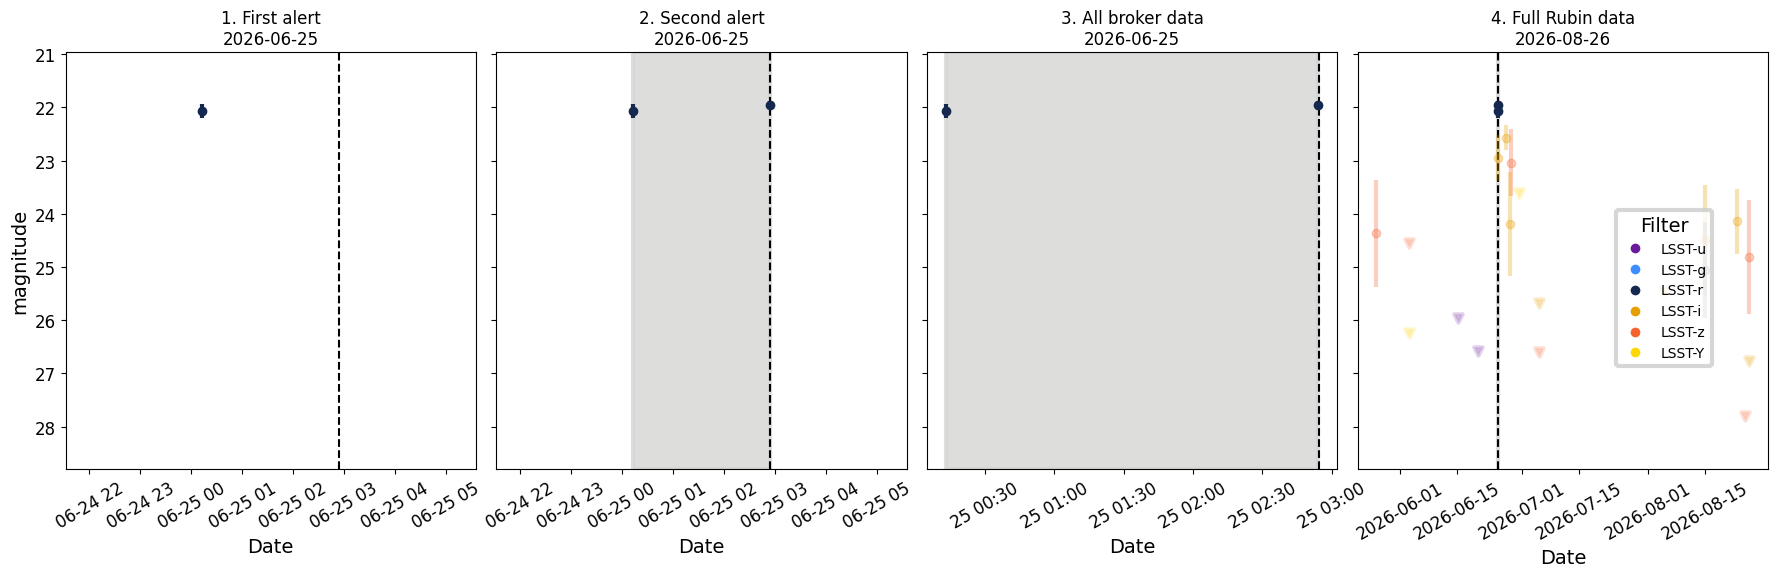

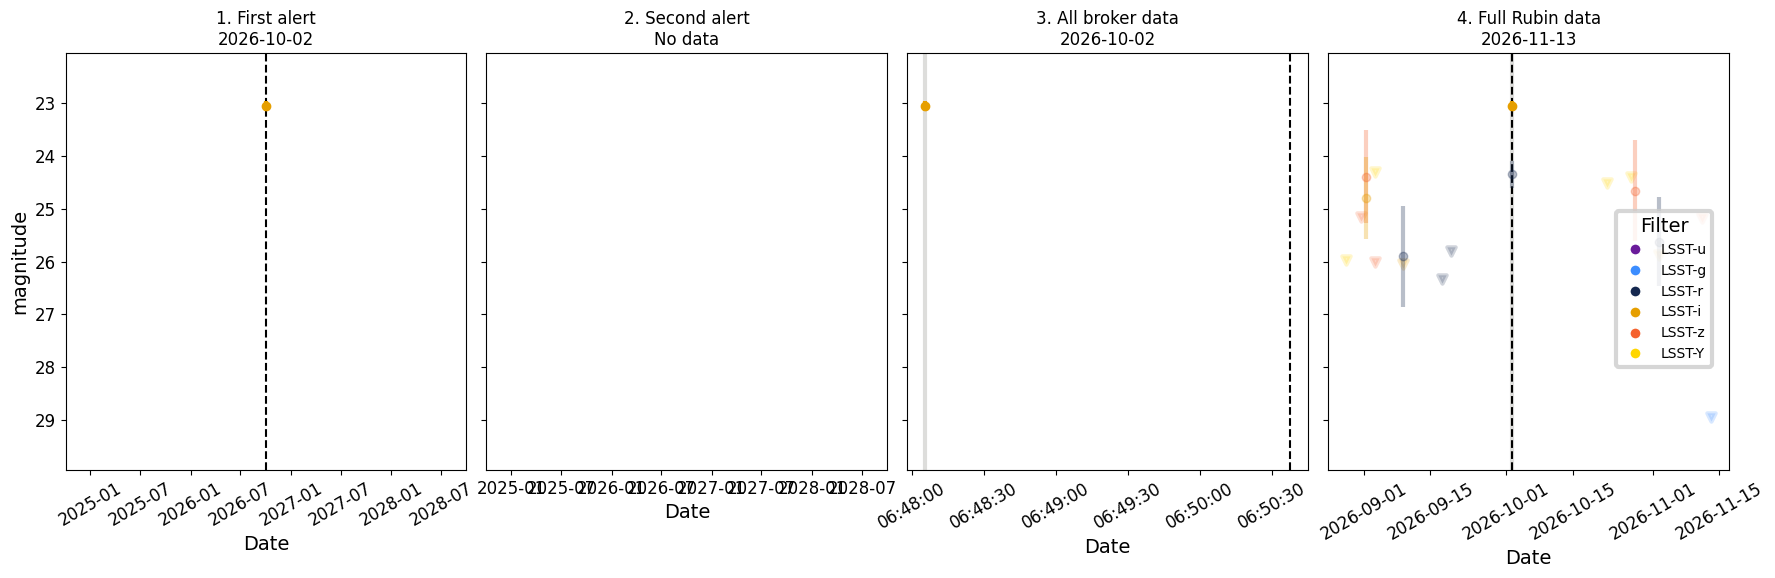

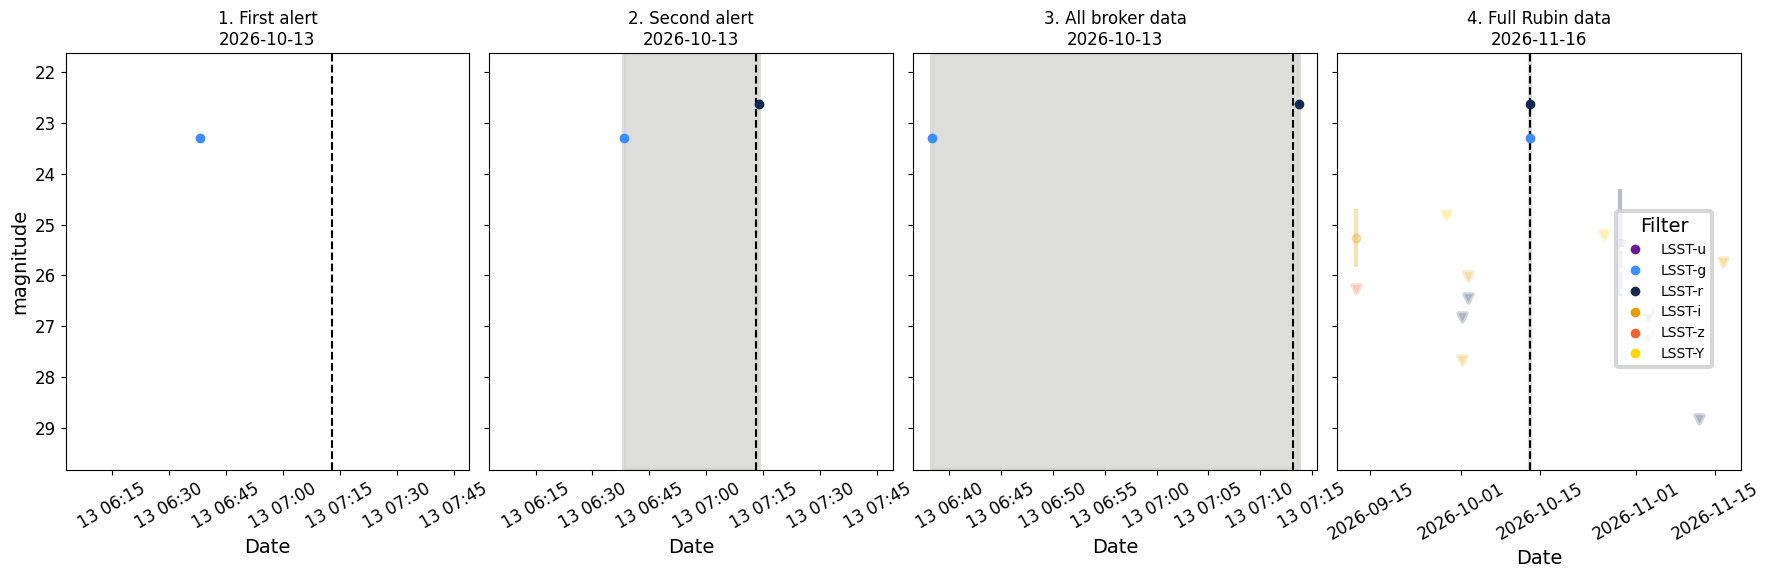

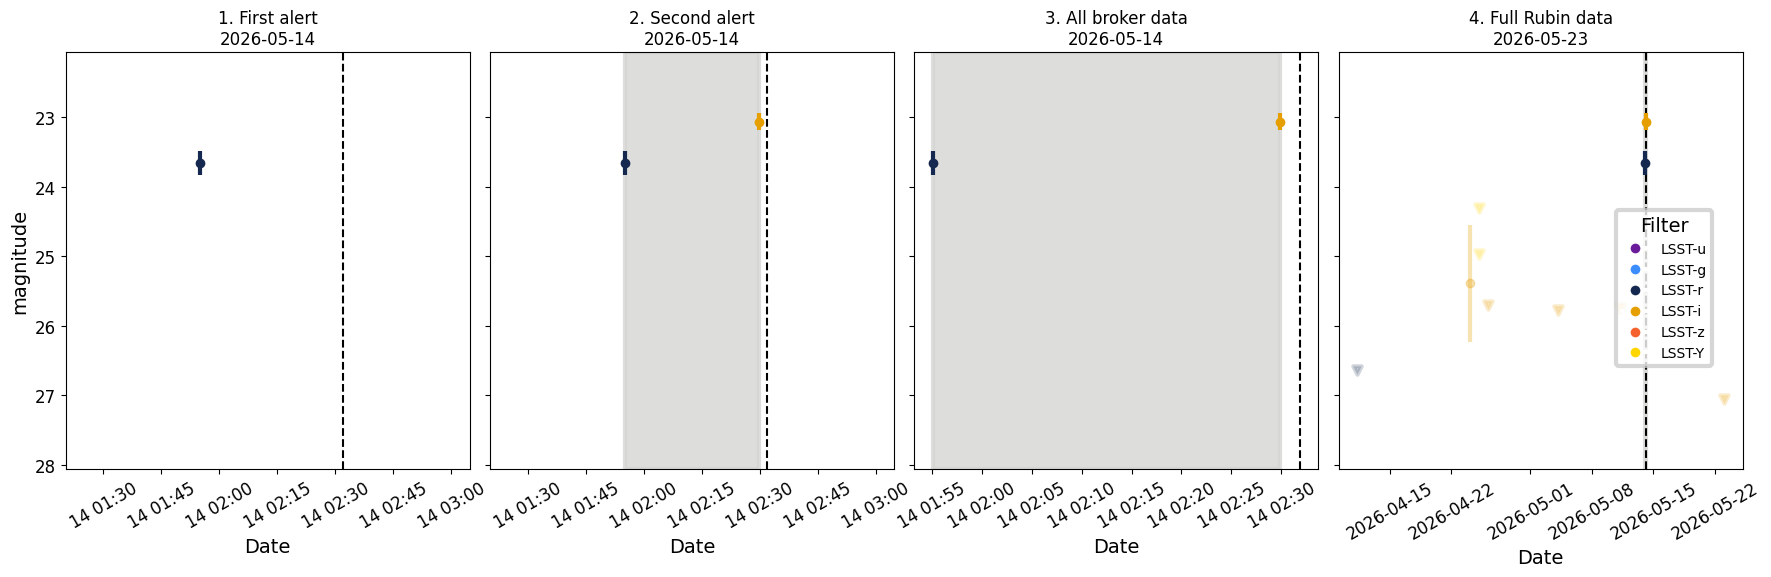

In [16]:
for idx in list(set(snids_all_snr_gt5))[:5]:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True)


# Best sampling

In [17]:
top_10_snids_by_magnitude_count = (
    df_phot[(df_phot['magnitude'].notnull()) & (df_phot['SNR']>5)]
    .groupby('SNID')
    .size()
    .sort_values(ascending=False)
    .head(15)
)


SNID 6571_Bulla z=0.06
SNID 12578_Bulla z=0.06
SNID 10572_Bulla z=0.10
SNID 3514_Kasen z=0.04
SNID 12264_Kasen z=0.06
SNID 3447_Kasen z=0.03
SNID 7790_Kasen z=0.02
SNID 12965_Kasen z=0.06
SNID 10386_Bulla z=0.03
SNID 5873_Bulla z=0.06
SNID 7376_Kasen z=0.04
SNID 6591_Kasen z=0.05
SNID 4636_Kasen z=0.03
SNID 12187_Kasen z=0.10
SNID 5123_Kasen z=0.11


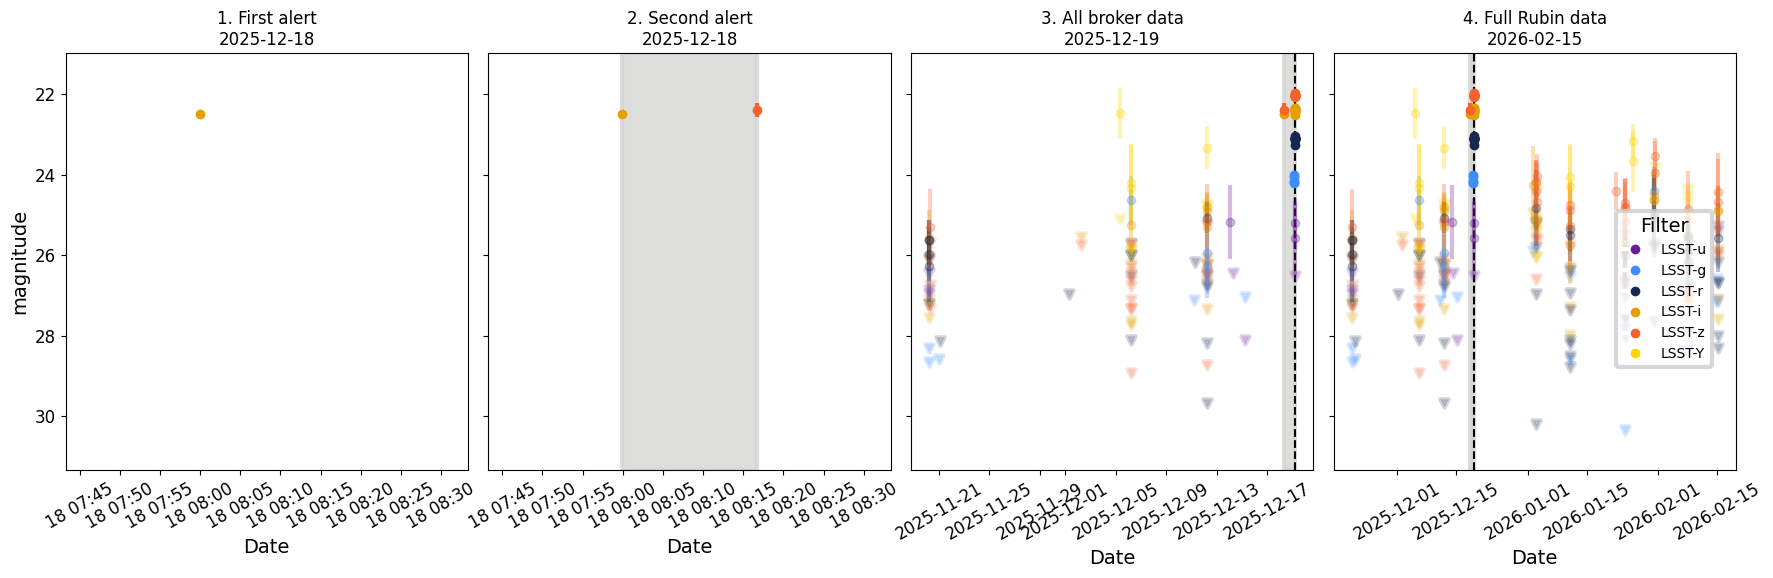

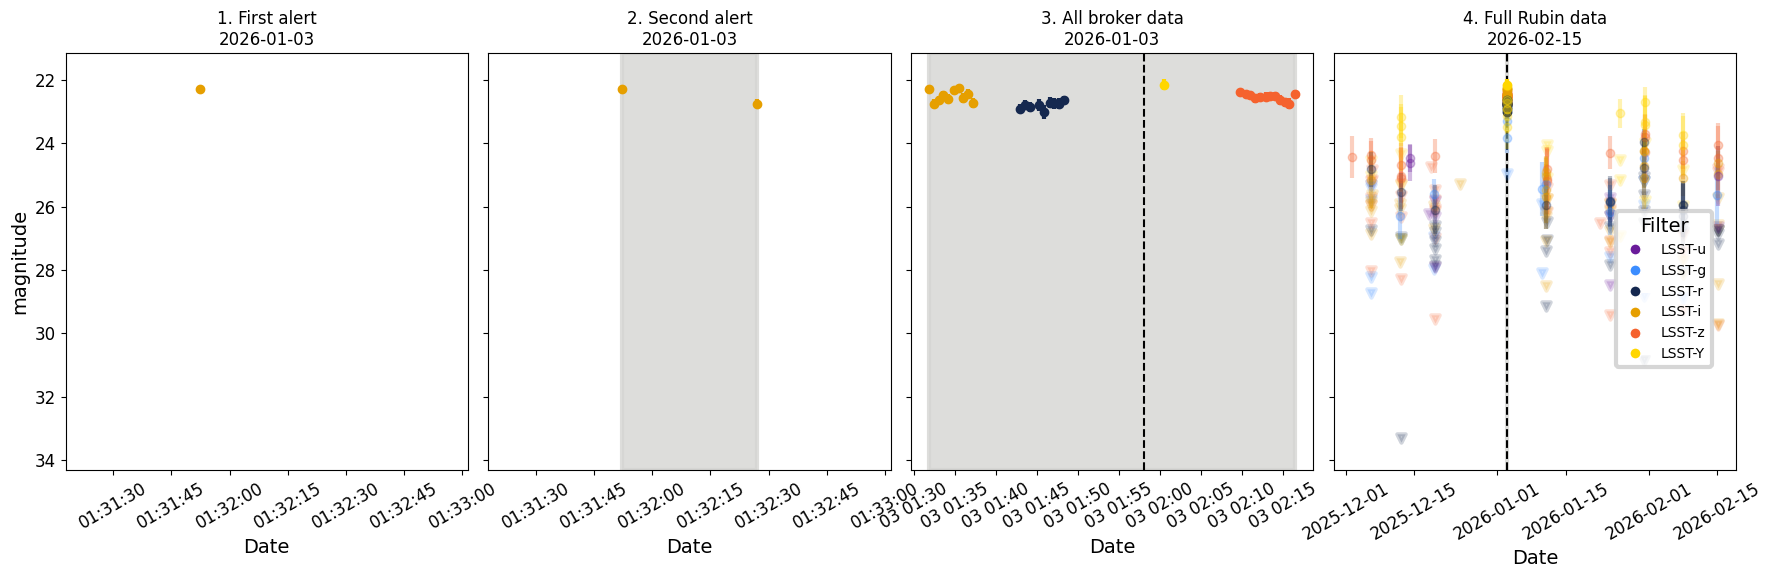

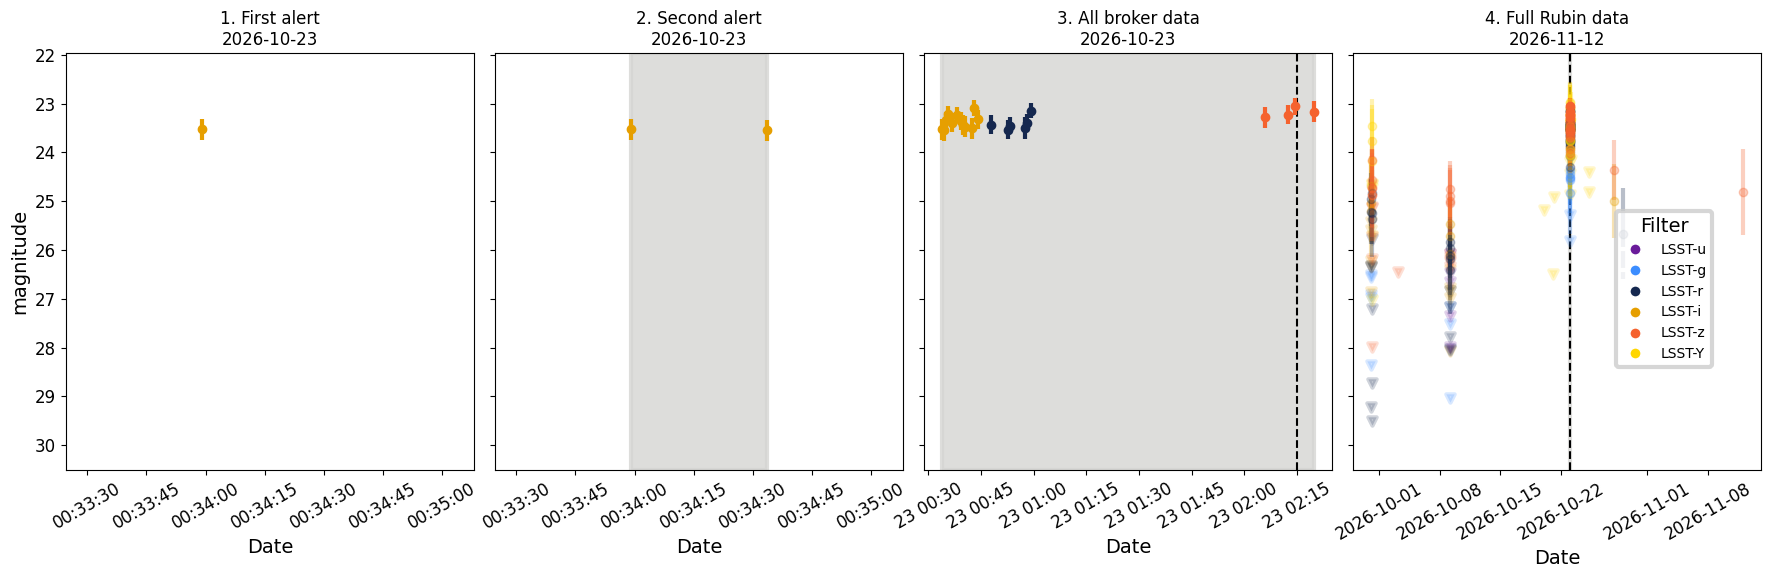

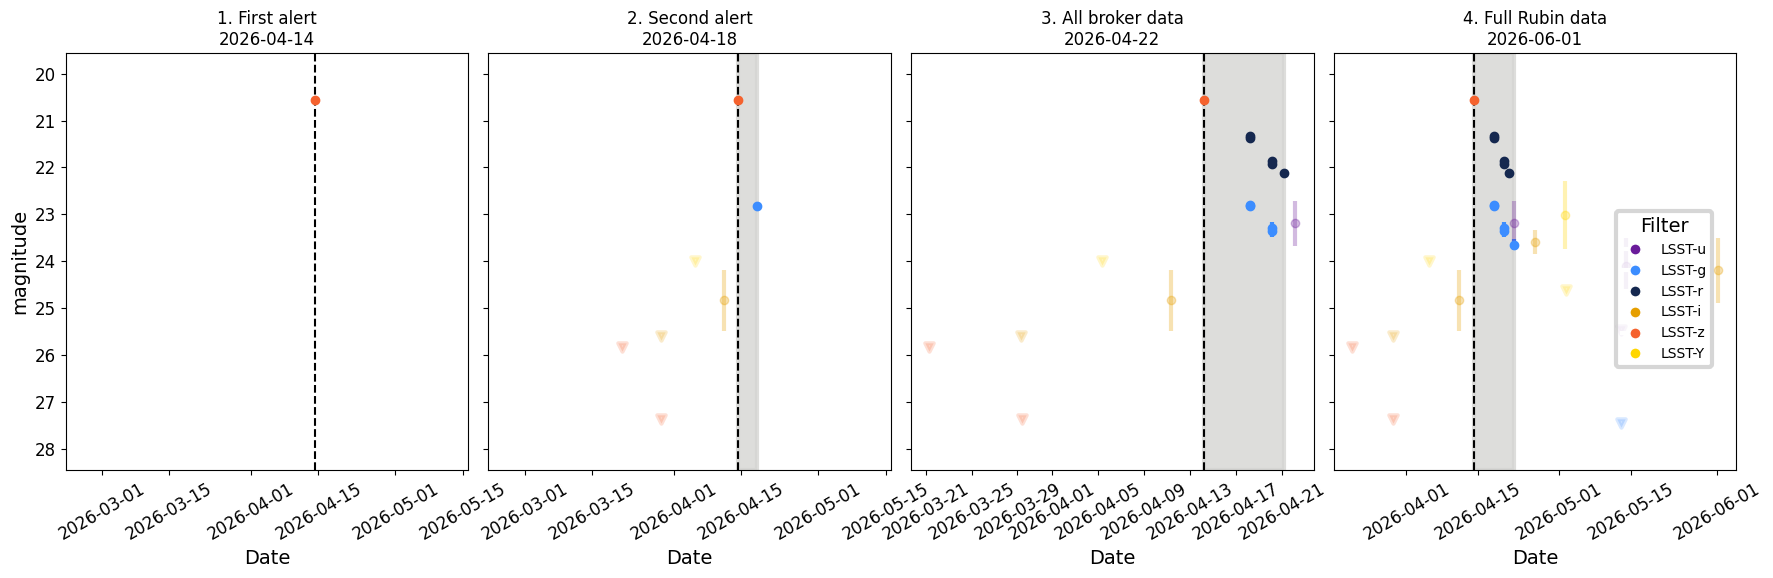

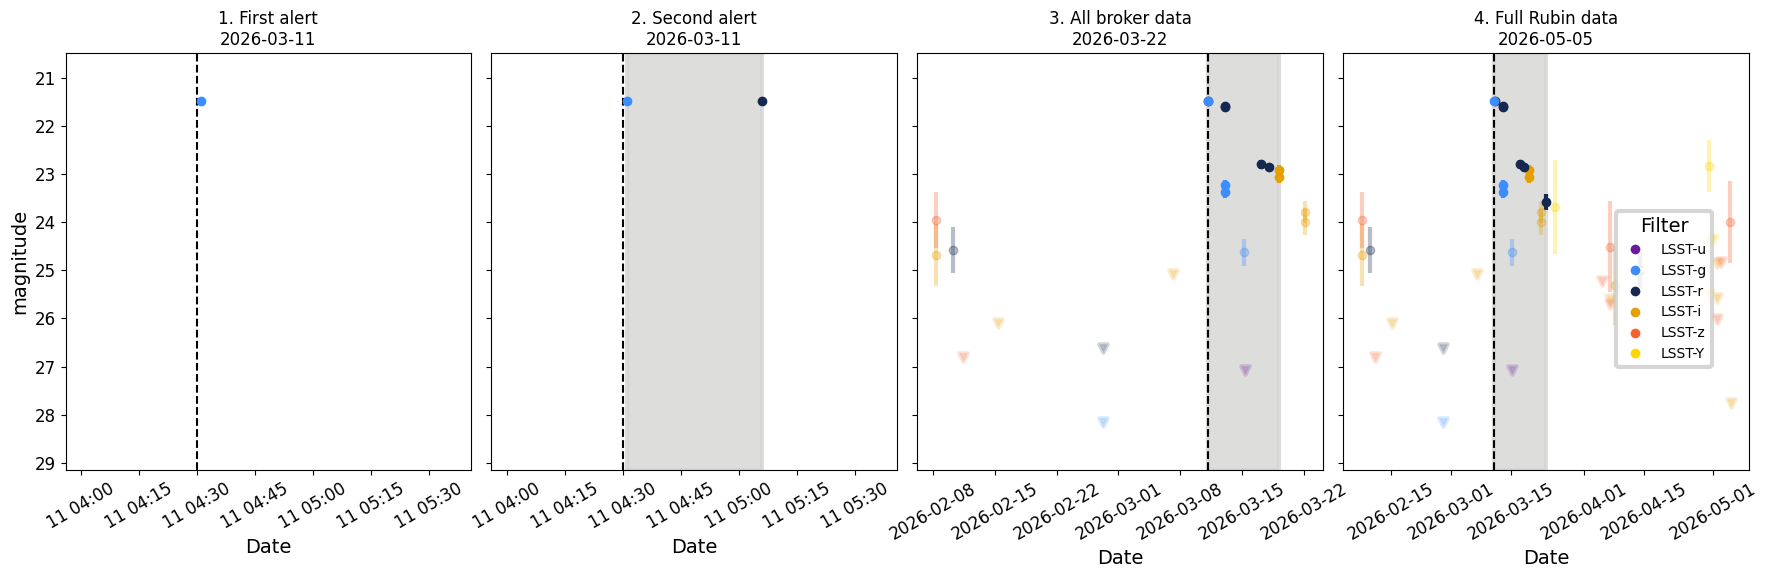

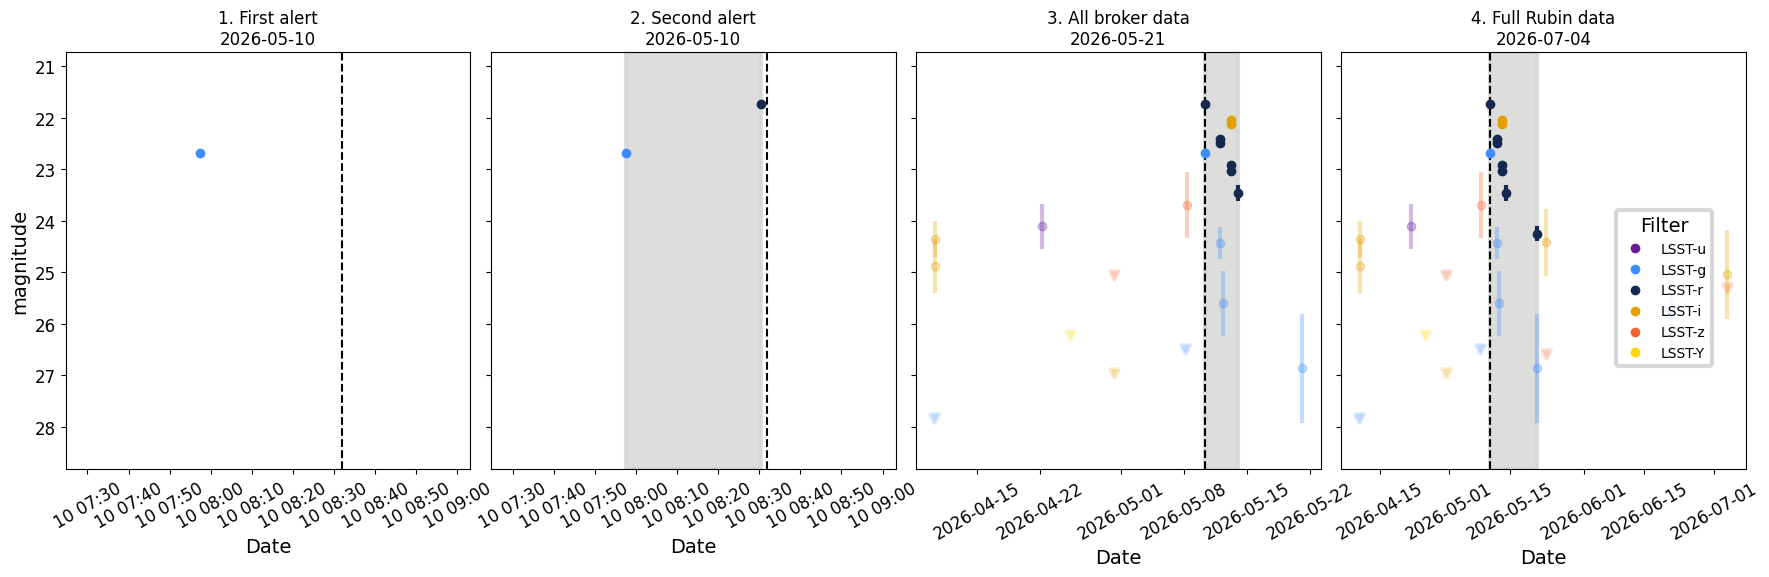

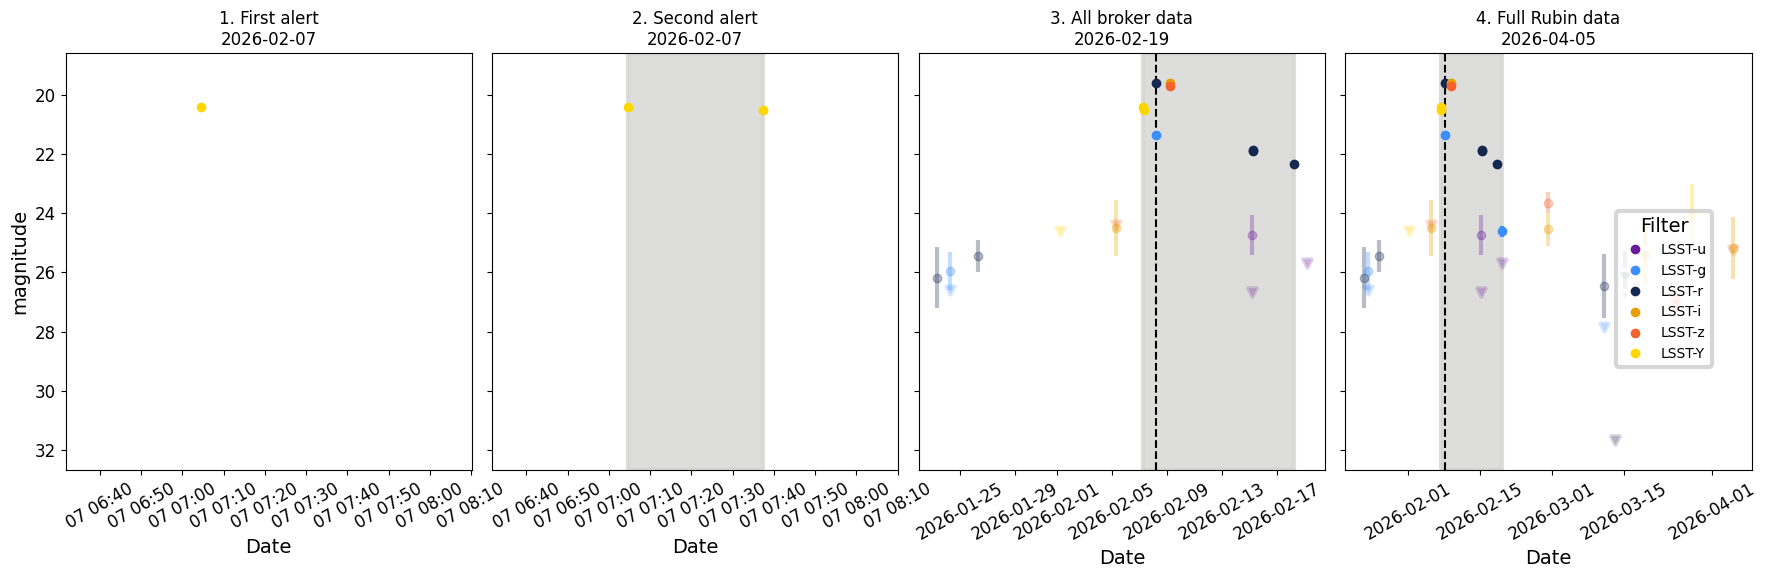

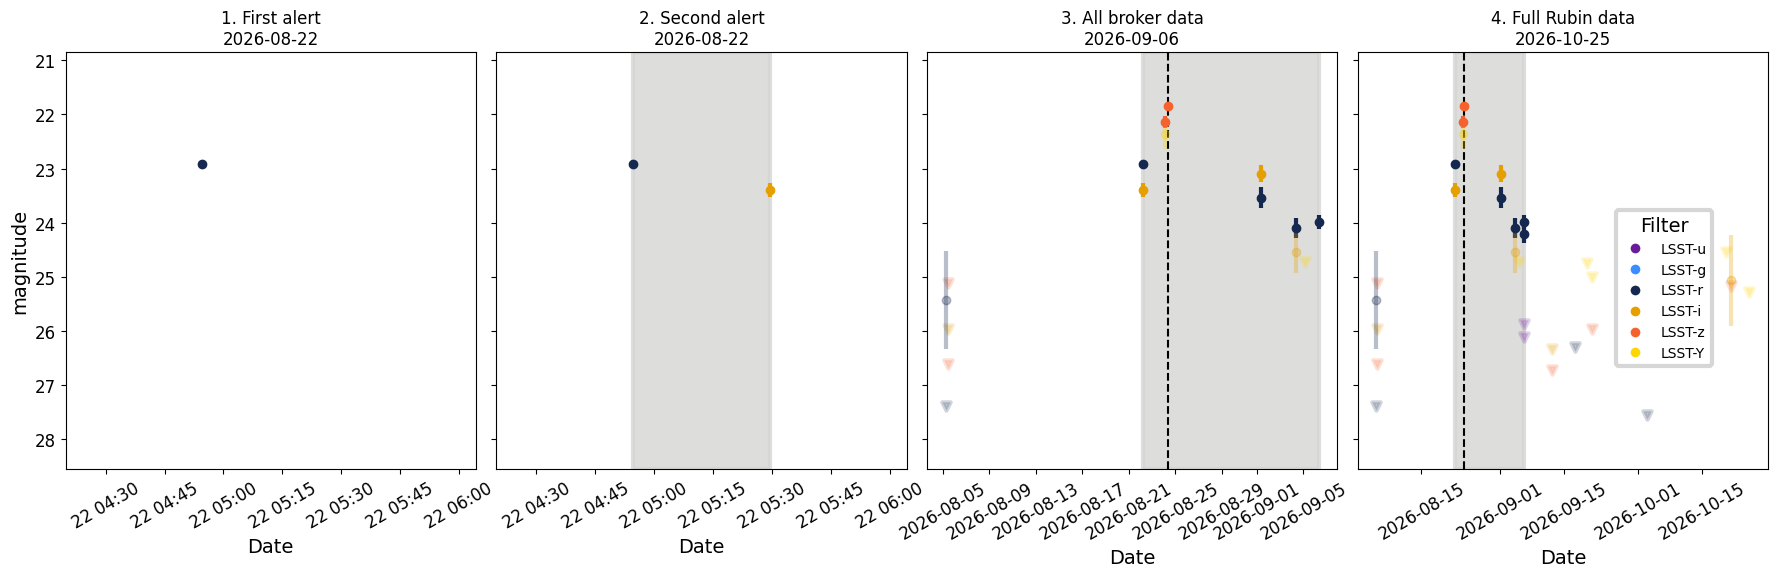

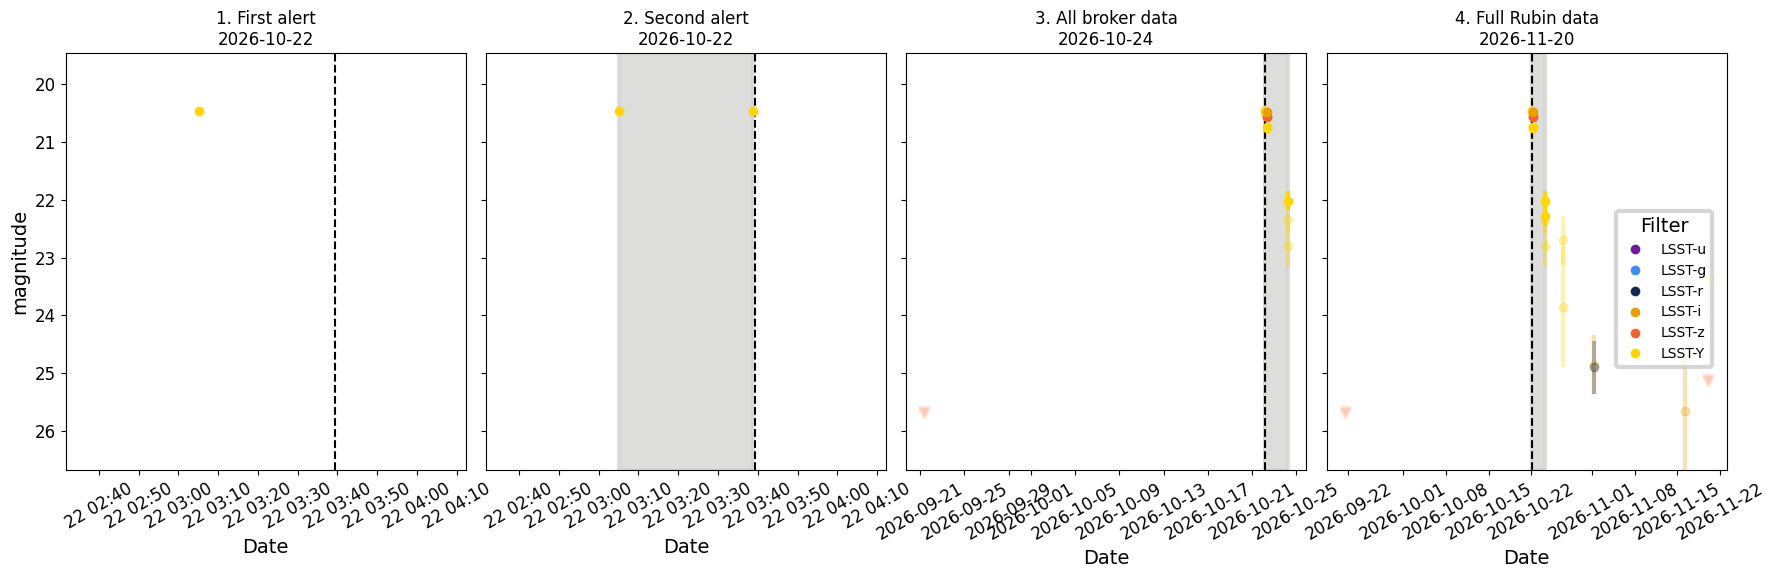

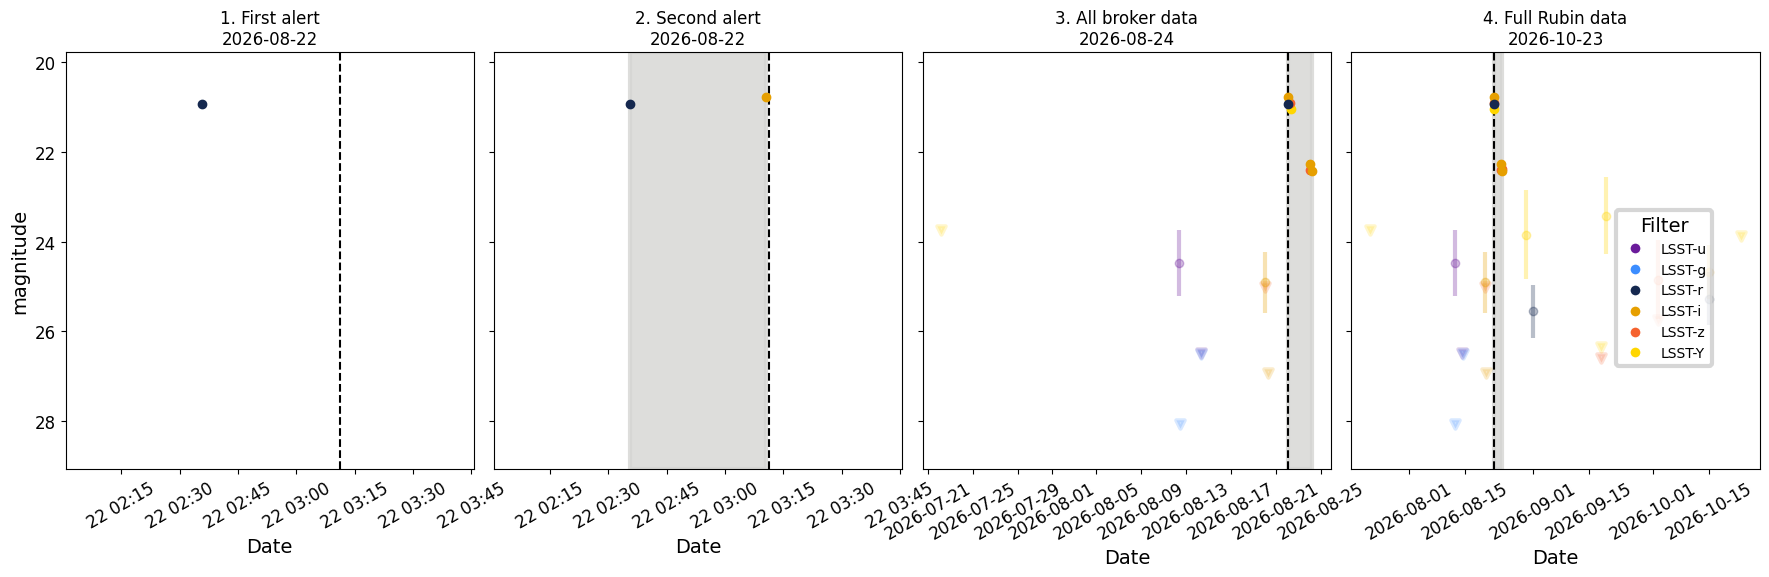

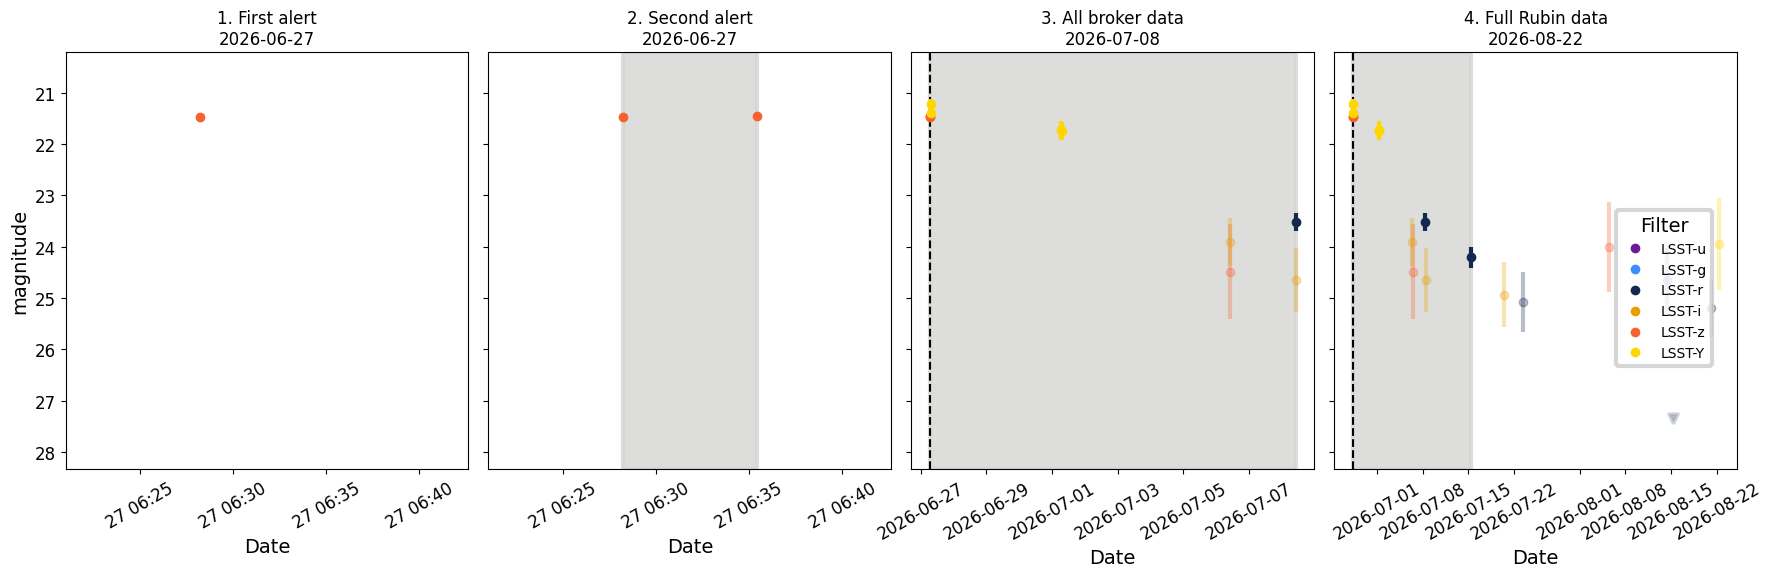

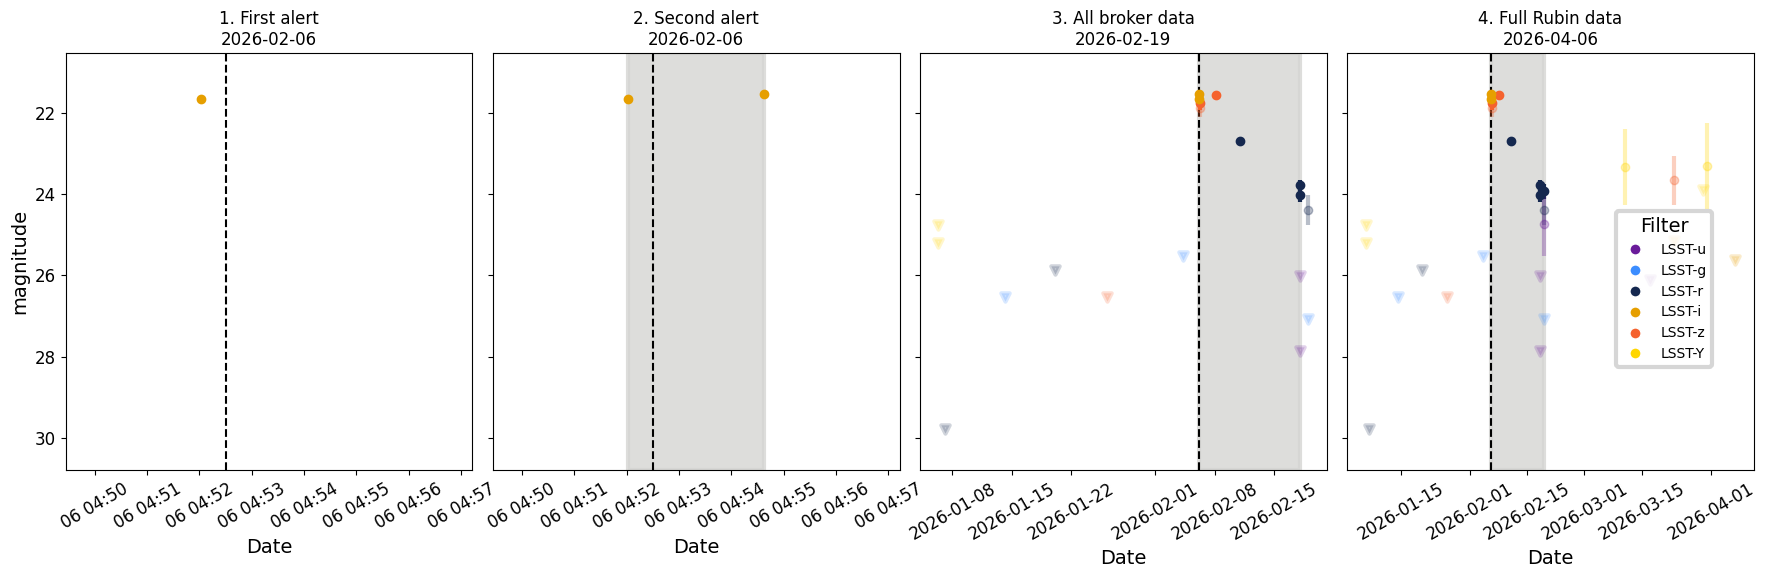

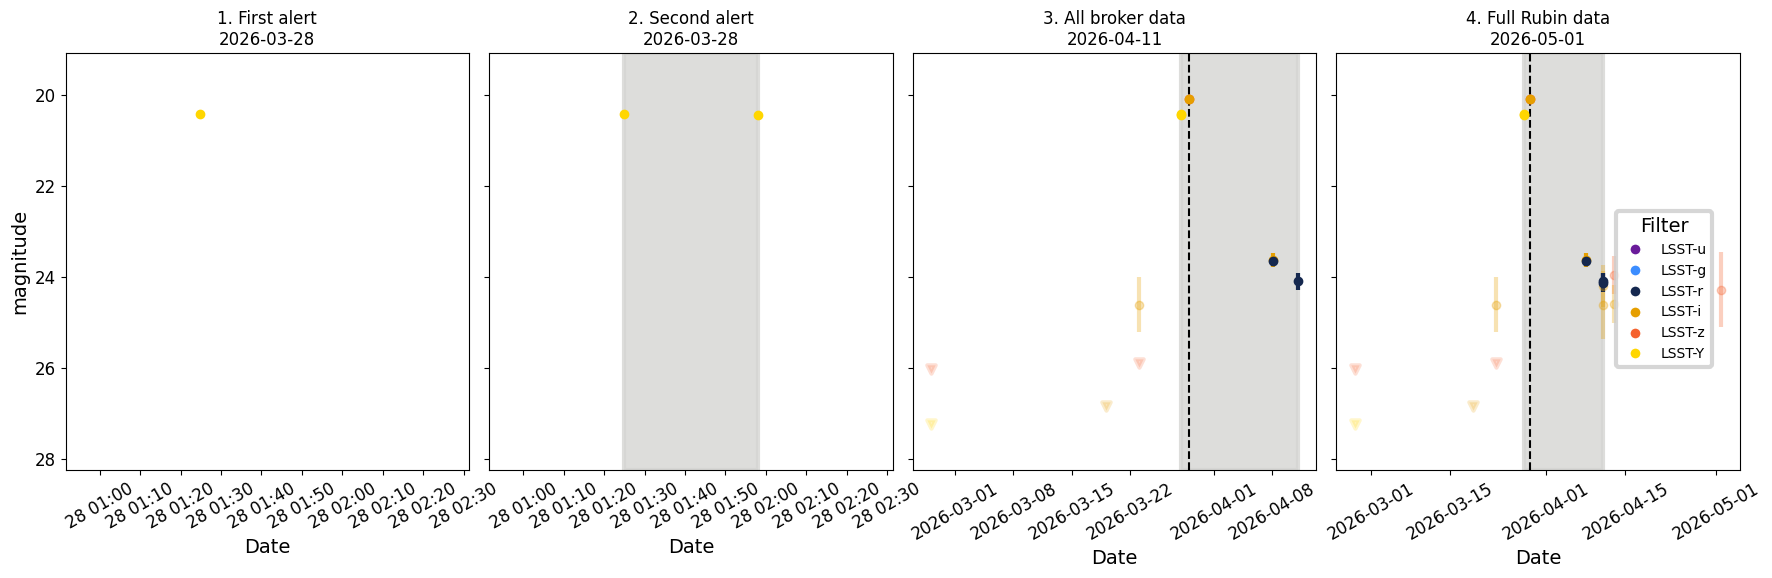

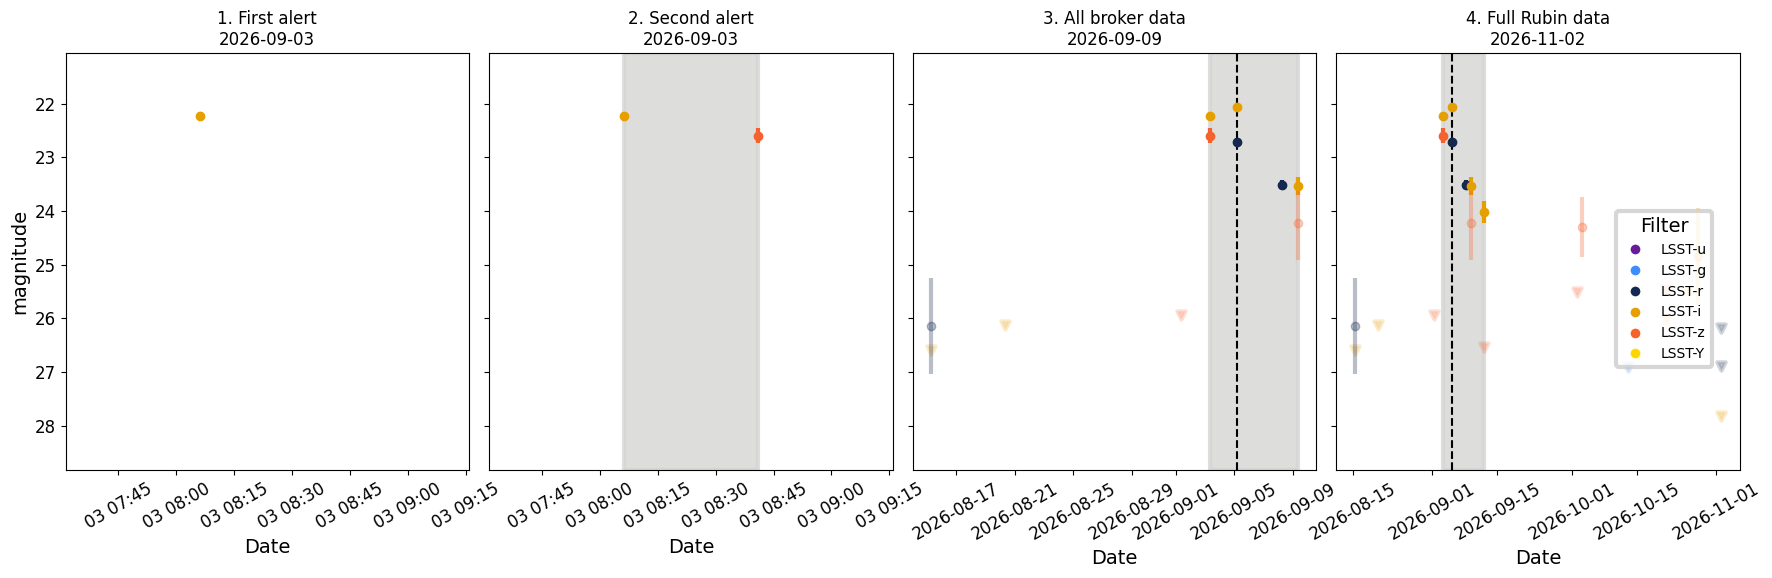

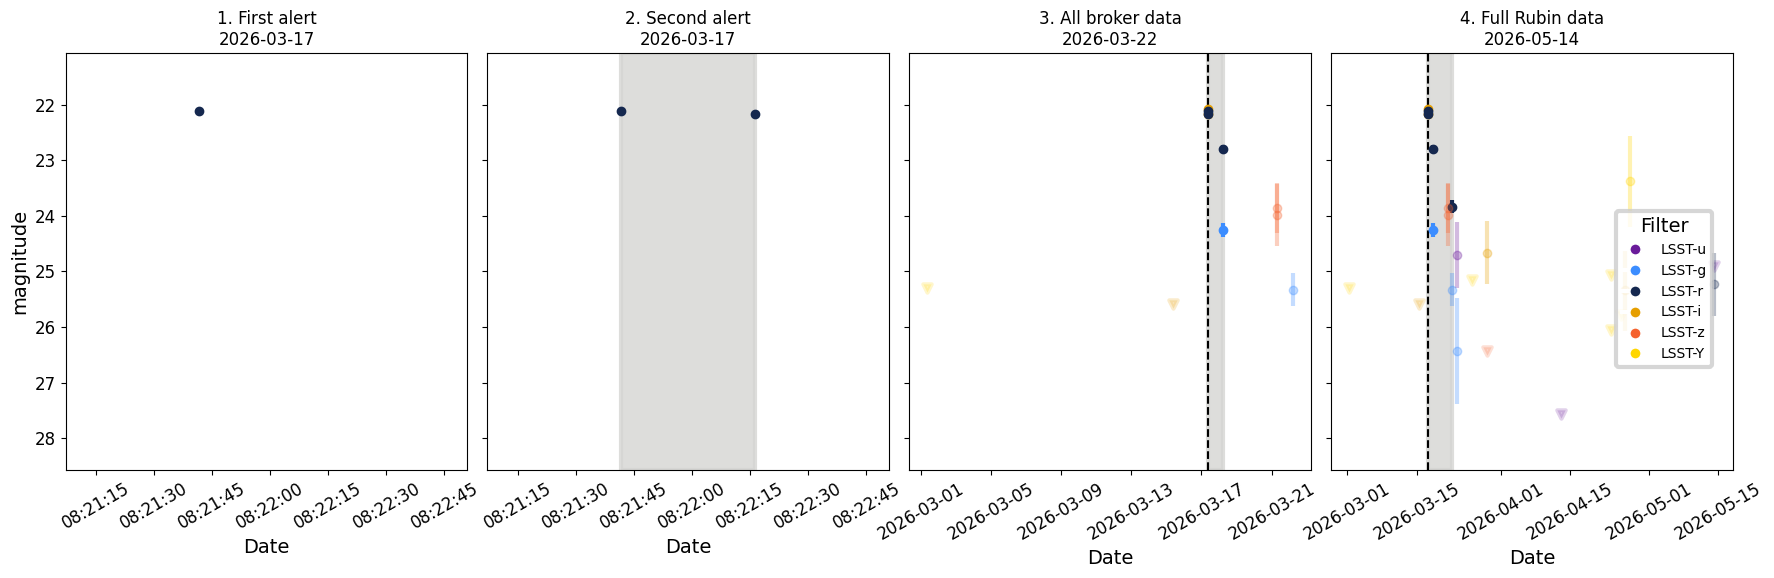

In [18]:
for idx in top_10_snids_by_magnitude_count.index:
    # plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)
    plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True, savefig=True)

# DDF + at least one detection in broker

In [19]:
# with_det_broker = df_phot[df_phot['SNR'] > 5]['SNID'].unique()
# to_plot = df_header[(df_header['in_ddf_field']) & (df_header['SNID'].isin(with_det_broker))].SNID.values
# print(f"Number of light curves in DDF fields with broker detections: {len(to_plot)} from {len(df_header[df_header['in_ddf_field']])} in DDF fields")
# for idx in to_plot:
#     plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)


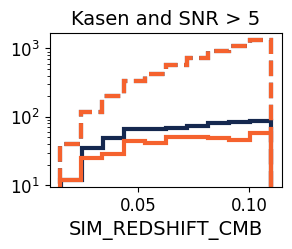

In [20]:
plt.figure(figsize=(3, 2))
for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header[df_header.SIM_GENTYPE == typ]
    sel = df_phot[(df_phot.SNID.isin(sel_header.SNID)) & (df_phot['SNR'] > 5)]
    idxs = sel[sel['SNR'] > 5]['SNID'].unique()
    plt.hist(sel_header['SIM_REDSHIFT_CMB'].dropna(), bins=10, color=dic_KN_models_colors[dic_sntype[str(typ)]], histtype='step',linestyle='dashed')
    plt.hist(sel_header[sel_header.SNID.isin(idxs)]['SIM_REDSHIFT_CMB'].dropna(), bins=10, color=dic_KN_models_colors[dic_sntype[str(typ)]],histtype='step')
    plt.xlabel('SIM_REDSHIFT_CMB')
    plt.title(f"{dic_sntype[str(typ)]} and SNR > 5")
    plt.yscale('log')

# How early are we detecting them?

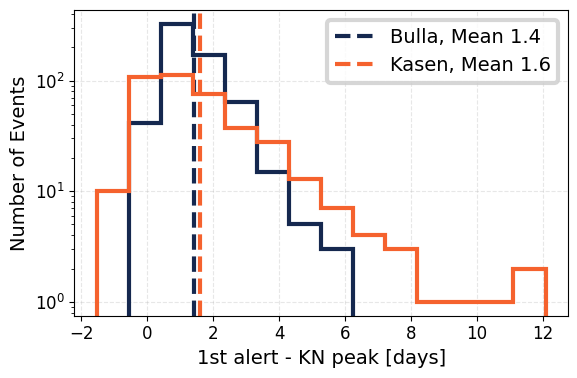

In [21]:
# Filter to SNR > 5 detections
snr5 = df_phot[df_phot['SNR'] > 5].copy()

# Get first MJD with SNR > 5 per SNID
first_snr5 = snr5.groupby('SNID')['MJD'].min().rename('first_snr5_mjd')

# Merge with header to align with PEAKMJD
df_header_w1stsnr5 = df_header.merge(first_snr5, on='SNID', how='left')

# Compute signed difference: PEAK - first SNR > 5
df_header_w1stsnr5['delta_snr5_peak'] = np.where(
    df_header_w1stsnr5['SIM_PEAKMJD'] > 0,
    df_header_w1stsnr5['first_snr5_mjd'] - df_header_w1stsnr5['SIM_PEAKMJD'],
    np.nan
)

# Histogram bins
bins = np.linspace(df_header_w1stsnr5['delta_snr5_peak'].min(), df_header_w1stsnr5['delta_snr5_peak'].max(), 15) 

plt.figure(figsize=(6, 4))

for typ in df_header_w1stsnr5.SIM_GENTYPE.unique():
    # Filter headers for current SN type
    sel_header = df_header_w1stsnr5[(df_header_w1stsnr5.SIM_GENTYPE == typ)].copy()
    
    # Drop NaNs
    data_snr5 = sel_header['delta_snr5_peak'].dropna()
    
    # Choose color per type
    color = dic_KN_models_colors[dic_sntype[str(typ)]]
    
    # Step histogram
    plt.hist(data_snr5, bins=bins, histtype='step', color=color)
    
    # Mean line
    mean_snr5 = data_snr5.mean()
    plt.axvline(mean_snr5, color=color, linestyle='dashed',
                label=f'{dic_sntype[str(typ)]}, Mean {mean_snr5:.1f}')
    
plt.xlabel('1st alert - KN peak [days]')
plt.ylabel('Number of Events')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('paper_plots/obsv43/first_alert_vs_peak.png')

Bulla 0.02119999999558786 0.714228408321823
Bulla 0.02239999999437714 0.3395365336271378
Kasen 0.021149999996850966 2.338962917076432
Kasen 1.9011499999978696 2.669115966951249


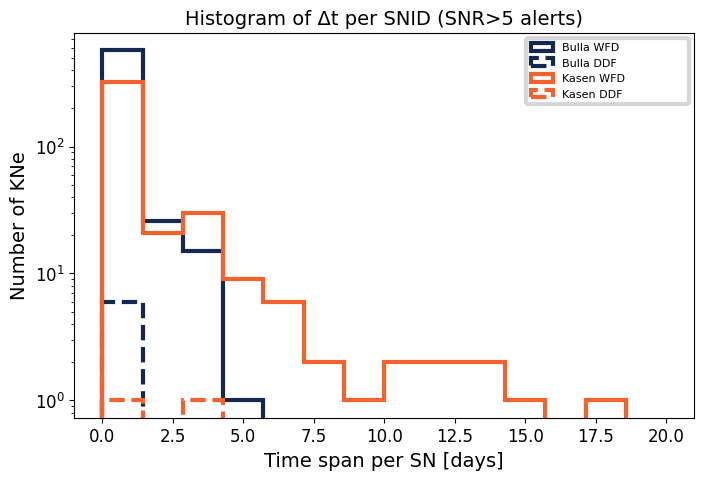

In [22]:
plt.figure(figsize=(8,5))
mybins = np.linspace(0, 20, 15)  # Adjust bins as needed

for mod in snr5['model_name'].unique():
    for f in snr5['FIELD'].unique():
        sel = snr5[(snr5['model_name'] == mod) & (snr5['FIELD'] == f)]
        if len(sel) == 0:
            continue
        
        # compute delta_times for this group only
        delta_times_group = sel.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
        
        # handle bytes or str
        f_str = f.decode() if isinstance(f, bytes) else f
        linestyle = '-' if 'WFD' in f_str else '--'
        plt.hist(delta_times_group, bins=mybins, histtype='step', color=dic_KN_models_colors.get(mod, 'k') , linestyle=linestyle, label=f"{mod} {f_str}")
        median_val = delta_times_group.median()
        print(mod,median_val,std_val := delta_times_group.std())

plt.xlabel("Time span per SN [days]")
plt.ylabel("Number of KNe")
plt.yscale("log")
plt.title("Histogram of Δt per SNID (SNR>5 alerts)")
plt.legend(fontsize=8)
plt.show()


In [23]:
# mydelta = snr5.groupby("SNID")["MJD"].agg(lambda x: x.max() - x.min())
# idxs = mydelta[mydelta>10].index
# for idx in idxs:
#     plot_lc_subplots_matplotlib(df_phot, df_header, idx, inmag=True, convert_date=True)


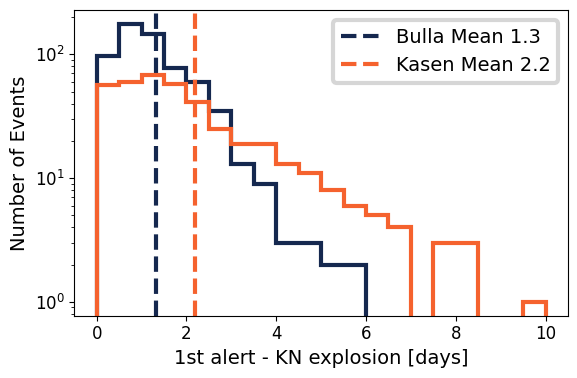

In [24]:
   
plt.figure(figsize=(6, 4))
bins = np.linspace(0, 10, 21)  # 10 bins between 0 and 10

for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header_w1stsnr5[df_header_w1stsnr5.SIM_GENTYPE == typ].copy()
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    
    # Compute delta between peak and explosion
    sel_header['delta_firstalert_explode'] = sel_header['first_snr5_mjd'] - sel_header['SIM_MJD_EXPLODE']

    # Choose color per type
    color = dic_KN_models_colors[dic_sntype[str(typ)]]
    
    # All events (dashed step)
    # plt.hist(data_all, bins=bins, histtype='step', linestyle='dashed', color=color,linewidth=1.5)
    
    # SNR>5 events (solid step)
    plt.hist(sel_header['delta_firstalert_explode'], bins=bins, histtype='step', color=color)

    mean_snr = sel_header['delta_firstalert_explode'].mean()
    plt.axvline(mean_snr, color=color, linestyle='dashed', 
                label=f'{dic_sntype[str(typ)]} Mean {mean_snr:.1f}')

plt.xlabel('1st alert - KN explosion [days]')
plt.ylabel('Number of Events')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.savefig('paper_plots/obsv43/first_alert_vs_explosion.png')
plt.show()


# How bright?

In [25]:
idx_max_flux = df_phot.groupby(['SNID', 'BAND'])['FLUXCAL'].idxmax()
df_max_flux = df_phot.loc[idx_max_flux].reset_index(drop=True)
# df_max_flux

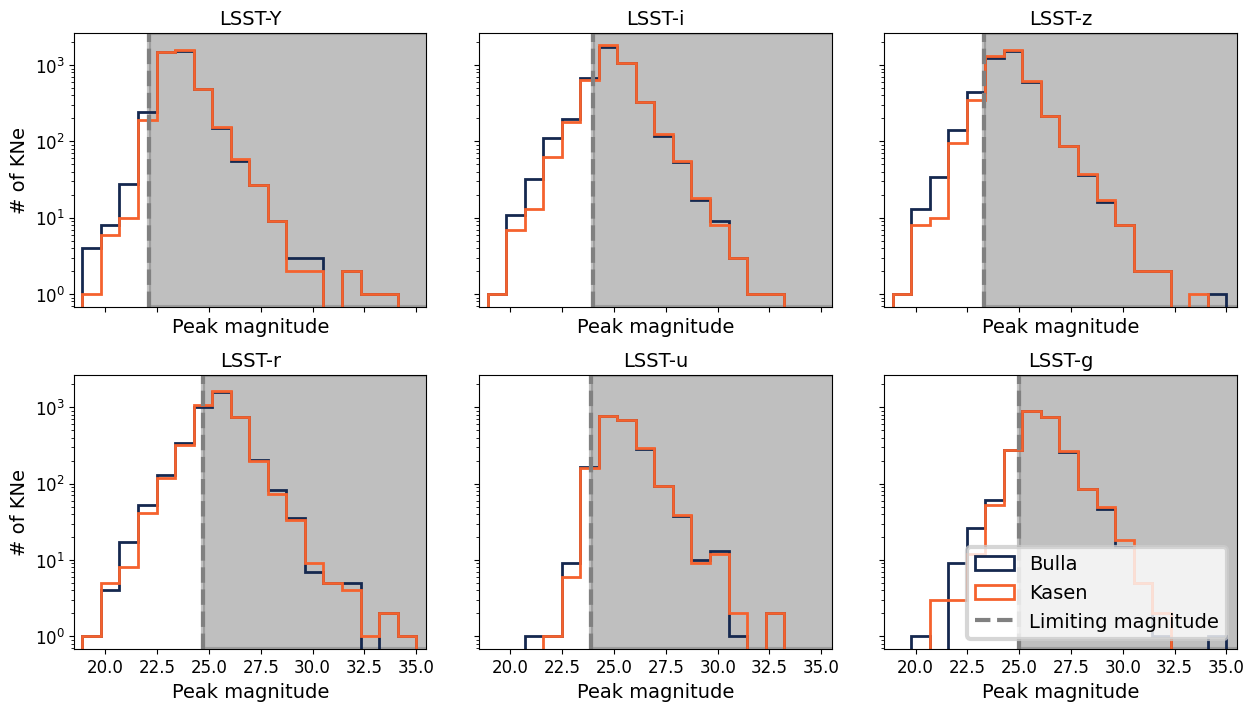

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0.15, hspace=0.25)

mybins = np.linspace(18, 35, 20)  # Bins for histogram

axes = axes.flatten()  # flatten 2x3 grid into 1D array for easy looping
bands = df_phot['BAND'].unique()
for ax, flt in zip(axes, bands):
    ax.set_title(flt)
    for mod in ['Bulla', 'Kasen']:
        sel_max_flux = df_max_flux[
            (df_max_flux['model_name']==mod) &
            (df_max_flux['BAND'] == flt)
        ]
        ax.hist(
            sel_max_flux['magnitude'],
            bins=mybins,
            label=mod,
            color=dic_KN_models_colors[mod],
            histtype='step',
            linewidth=2,
        )

    # vertical line + shaded region
    ax.axvline(x=dic_limiting_mags[flt], color='grey', linestyle='--', label='Limiting magnitude')
    ax.axvspan(dic_limiting_mags[flt], ax.get_xlim()[1], color='grey', alpha=0.5)

    ax.set_xlabel("Peak magnitude")

# shared y-label
axes[0].set_ylabel("# of KNe")
axes[3].set_ylabel("# of KNe")  # also label the 2nd row

plt.yscale("log")
plt.xlim(18.5, 35.5)
plt.legend()
plt.savefig('paper_plots/obsv43/hist_mags.png')
plt.show()



In [ ]:
# Merge redshift into the max flux dataframe
df_with_z = df_max_flux.merge(
    df_header[['SNID', 'SIM_REDSHIFT_CMB']], 
    on='SNID', how='left'
)
bands = df_with_z['BAND'].unique()
fig, axes = plt.subplots(1, len(bands), figsize=(7*len(bands), 8), sharey=True, sharex=False)

for ax, flt in zip(axes, bands):
    ax.set_title(flt)
    for mod in ['Bulla', 'Kasen']:
        sel = df_with_z[
            (df_with_z['model_name'] == mod) &
            (df_with_z['BAND'] == flt)
        ]
        ax.scatter(
            sel['SIM_REDSHIFT_CMB'], sel['magnitude'],
            s=10, alpha=0.6,
            label=mod,
            color=dic_KN_models_colors[mod]
        )

    # limiting magnitude line (horizontal this time)
    ax.axhline(y=dic_limiting_mags[flt], color='grey', linestyle='--')
    ax.fill_between(
        [0, df_header['SIM_REDSHIFT_CMB'].max()],  # x-range
        dic_limiting_mags[flt],  # lower bound
        df_phot['magnitude'].max(),        # upper bound
        color='grey', alpha=0.3
    )
    ax.set_xlabel("Redshift")
    
axes[0].set_ylabel("Peak magnitude")
plt.ylim(18, 27)
plt.legend()
plt.tight_layout()
plt.show()


### is there a more predominant color we can use?

In [ ]:
pairs = []
for snid, group in df_max_flux.groupby("SNID"):
    group = group.sort_values("MJD")

    for i, row1 in group.iterrows():
        for j, row2 in group.iterrows():
            if row1.BAND == row2.BAND:
                continue
            dt = abs(row1.MJD - row2.MJD)
            if dt <= 0.7:
                # enforce a consistent band ordering
                band1, band2 = sorted([row1.BAND, row2.BAND])
                if band1 == row1.BAND:
                    mag1, mag2 = row1.magnitude, row2.magnitude
                    snr1, snr2 = row1.SNR, row2.SNR
                else:
                    mag1, mag2 = row2.magnitude, row1.magnitude
                    snr1, snr2 = row2.SNR, row1.SNR

                mag_diff = mag1 - mag2
                colour = f"{band1}-{band2}"

                pairs.append({
                    "SNID": snid,
                    "BAND1": band1,
                    "BAND2": band2,
                    "MJD1": row1.MJD,
                    "MJD2": row2.MJD,
                    "MAG1": mag1,
                    "MAG2": mag2,
                    "dt": dt,
                    "colour": colour,
                    "mag_diff": mag_diff,
                    "SNR1": snr1,
                    "SNR2": snr2,
                    "model":row1.SNID.split("_")[1]
                })

df_colours = pd.DataFrame(pairs).drop_duplicates(
    subset=["SNID", "BAND1", "BAND2", "MJD1", "MJD2"]
).reset_index(drop=True)


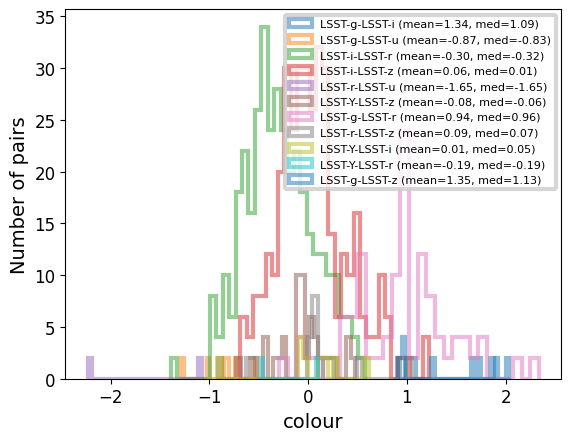

In [ ]:
for c in df_colours.colour.unique():
    sel = df_colours[
        (df_colours.colour == c) & 
        (df_colours.SNR1 > 5) & 
        (df_colours.SNR2 > 5)
    ]
    if len(sel) == 0:
        continue
    
    mean_val = sel.mag_diff.mean()
    median_val = sel.mag_diff.median()
    
    # histogram
    plt.hist(sel.mag_diff, bins=30, alpha=0.5, label=f"{c} (mean={mean_val:.2f}, med={median_val:.2f})", histtype='step')
    
    # print colours
    # print(c)
    # print('mean',round(mean_val,1))
    # print('median',round(median_val,1))

plt.xlabel("colour")
plt.ylabel("Number of pairs")
plt.legend(fontsize=8)


In [ ]:
df_colours_broker = df_colours[(df_colours.SNR1 > 5) & (df_colours.SNR2 > 5)]
for mod in df_colours_broker.model.unique():
    sel = df_colours_broker[df_colours_broker.model == mod]
    print(f"{mod} Min-max colours from KNe: {sel.mag_diff.min():.1f} {sel.mag_diff.max():.1f}")

Bulla Min-max colours from KNe: -1.3 2.0
Kasen Min-max colours from KNe: -2.2 2.3


Bulla LSST-i-LSST-r mean=-0.35, std=0.26, median=-0.37
Kasen LSST-i-LSST-r mean=-0.21, std=0.44, median=-0.22


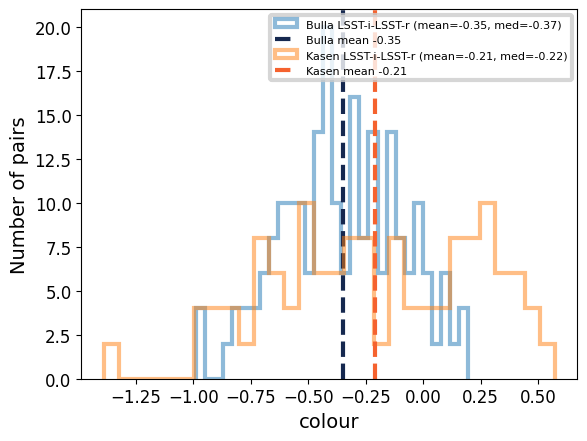

In [ ]:
# Only i-r
c = 'LSST-i-LSST-r'
for mod in df_colours_broker.model.unique():
    sel = df_colours[
        (df_colours.colour == c) & 
        (df_colours.SNR1 > 5) & 
        (df_colours.SNR2 > 5) & (df_colours.model == mod)
    ]

    mean_val = sel.mag_diff.mean()
    std_val = sel.mag_diff.std()
    median_val = sel.mag_diff.median()

    # histogram
    plt.hist(sel.mag_diff, bins=30, alpha=0.5, label=f"{mod} {c} (mean={mean_val:.2f}, med={median_val:.2f})", histtype='step')
    plt.axvline(mean_val, color=dic_KN_models_colors[mod], linestyle='--', label=f"{mod} mean {mean_val:.2f}")
    print(f"{mod} {c} mean={mean_val:.2f}, std={std_val:.2f}, median={median_val:.2f}")

plt.xlabel("colour")
plt.ylabel("Number of pairs")
plt.legend(fontsize=8)


## Rate of decline

LSST-Y median 0.2 +- 0.4
LSST-i median 0.4 +- 0.4
LSST-r median 0.3 +- 0.4
LSST-u median 2.0 +- nan
LSST-z median 0.3 +- 0.4
LSST-g median 0.5 +- 0.3


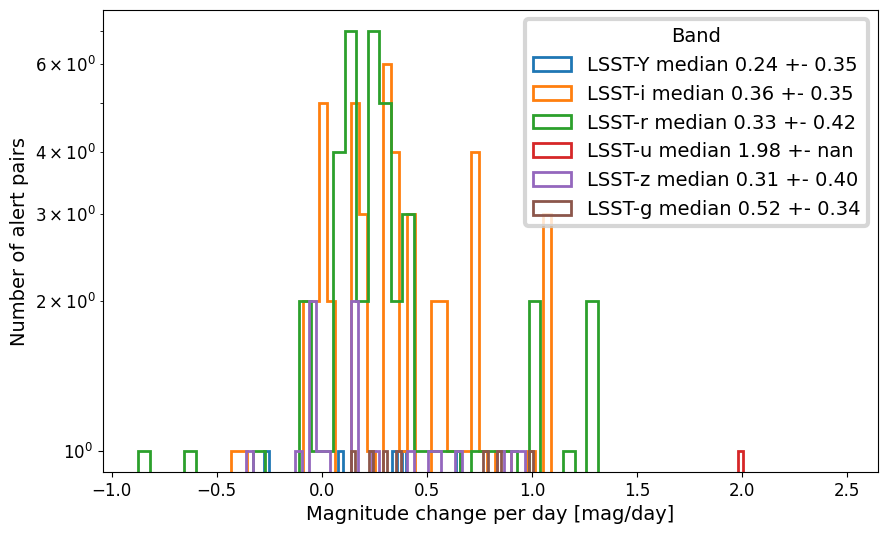

In [ ]:
# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
# sort by SNID and BAND
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# differences
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# only compute rate if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]



plt.figure(figsize=(10,6))

for band in bands:
    sel = df_snr[df_snr["BAND"] == band]
    plt.hist(
        sel["rate_mag_per_day"].dropna(),
        bins=40,
        histtype="step",
        label=f"{band} median {sel['rate_mag_per_day'].mean():.2f} +- {sel['rate_mag_per_day'].std():.2f}",
        linewidth=2
    )
    print(f"{band} median {sel['rate_mag_per_day'].mean():.1f} +- {sel['rate_mag_per_day'].std():.1f}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend(title="Band")
plt.show()



Kasen median 0.2 +- 0.3
Bulla median 0.6 +- 0.5


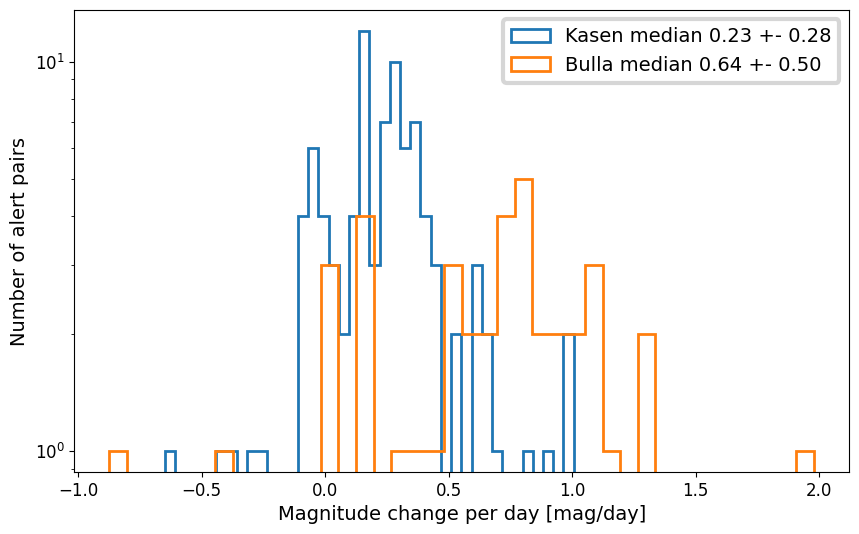

In [ ]:
# no band distinction

# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
# sort by SNID and BAND
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# differences
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# only compute rate if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]

df_snr['model'] = df_snr['SNID'].apply(lambda x: x.split('_')[1] if '_' in x else 'Unknown')

plt.figure(figsize=(10,6))

for mod in df_snr.model.unique():
    sel = df_snr[df_snr["model"] == mod]
    plt.hist(
        sel["rate_mag_per_day"].dropna(),
        bins=40,
        histtype="step",
        label=f"{mod} median {sel['rate_mag_per_day'].mean():.2f} +- {sel['rate_mag_per_day'].std():.2f}",
        linewidth=2
    )
    print(f"{mod} median {sel['rate_mag_per_day'].mean():.1f} +- {sel['rate_mag_per_day'].std():.1f}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend()
plt.show()



Kasen LSST-Y: median=0.22, std=0.31, N=4
Kasen LSST-i: median=0.27, std=0.26, N=34
Kasen LSST-r: median=0.26, std=0.26, N=41
Kasen LSST-z: median=-0.03, std=0.32, N=7
Kasen LSST-g: median=0.33, std=0.35, N=6
Bulla LSST-Y: median=0.66, std=nan, N=1
Bulla LSST-i: median=0.71, std=0.38, N=20
Bulla LSST-r: median=0.99, std=0.69, N=9
Bulla LSST-u: median=1.98, std=nan, N=1
Bulla LSST-z: median=0.53, std=0.38, N=9
Bulla LSST-g: median=0.78, std=nan, N=1


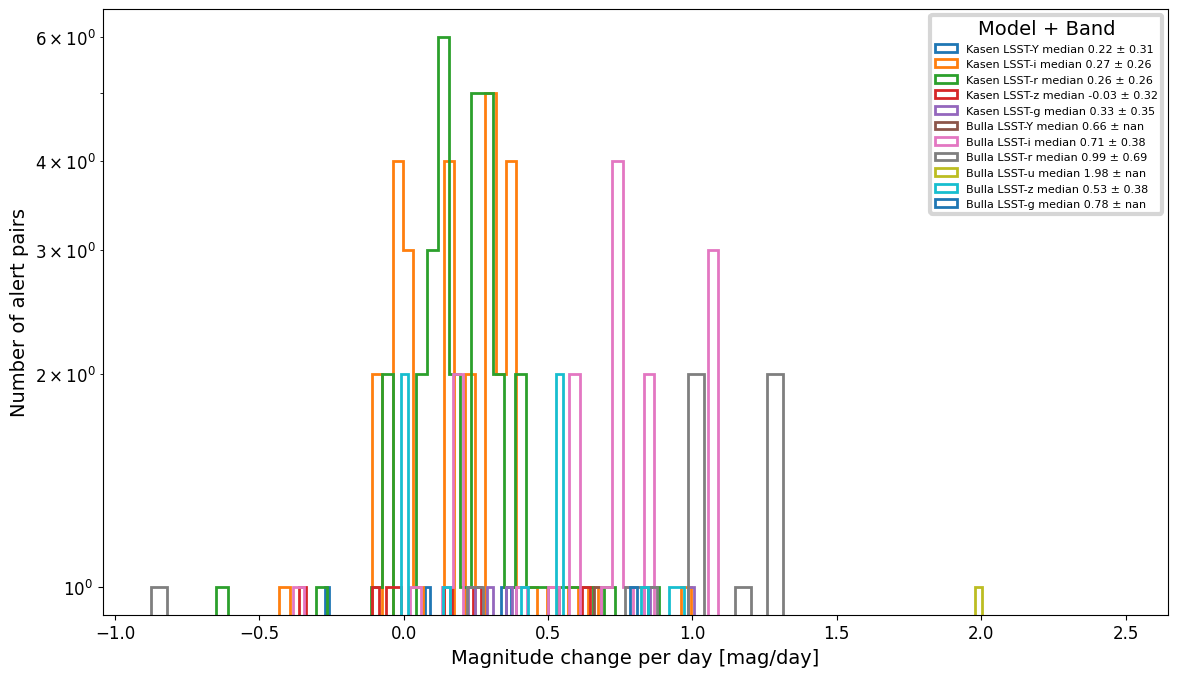

In [ ]:
import matplotlib.pyplot as plt

# get all the SNR>5 alerts
df_snr = df_phot[df_phot["SNR"] > 5].copy()
df_snr = df_snr.sort_values(["SNID", "BAND", "MJD"])

# compute differences within each SNID × BAND
df_snr["dm"] = df_snr.groupby(["SNID", "BAND"])["magnitude"].diff()
df_snr["dt"] = df_snr.groupby(["SNID", "BAND"])["MJD"].diff()

# rate, only if dt > 1
df_snr["rate_mag_per_day"] = df_snr["dm"].where(df_snr["dt"] > 1) / df_snr["dt"]

# extract model name from SNID (assumes format like "123_Bulla")
df_snr["model"] = df_snr["SNID"].apply(lambda x: x.split("_")[1] if "_" in x else "Unknown")

# plot
plt.figure(figsize=(12,7))

for mod in df_snr["model"].unique():
    for band in bands:
        sel = df_snr[(df_snr["BAND"] == band) & (df_snr["model"] == mod)]["rate_mag_per_day"].dropna()
        if len(sel) == 0:
            continue

        median_val = sel.median()
        std_val = sel.std()

        plt.hist(
            sel,
            bins=40,
            histtype="step",
            linewidth=2,
            label=f"{mod} {band} median {median_val:.2f} ± {std_val:.2f}"
        )
        print(f"{mod} {band}: median={median_val:.2f}, std={std_val:.2f}, N={len(sel)}")

plt.xlabel("Magnitude change per day [mag/day]")
plt.ylabel("Number of alert pairs")
plt.yscale("log")
plt.legend(fontsize=8, title="Model + Band")
plt.tight_layout()
plt.show()
